# Task 2 Hybrid Spike Localization Model

This notebook improves the current C4 model using the evaluation findings from the factorized run.

Main changes:
- keep the flexible C4 direct logit decoder, because the pure factorized model was too smooth;
- hard-mask globally impossible time bins 0-5;
- train with BCE plus focal positive-bin loss, hard-negative ranking loss, joint spatial-temporal KL, count, timing, and spatial losses;
- select checkpoints by the full localization-aware validation loss, not plain BCE alone.


In [1]:
# ===== notebook cell 2 =====
# ============================================================
# 1. Imports
# ============================================================
import os
import sys

PROJECT_ROOT = "/home/bnn_10fs26/pands_ibnnwml/Final_Task"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.data import load_data, save_data
try:
    from utils.plotting import map_colour_to_electrode
except Exception as e:
    map_colour_to_electrode = None
    print("WARNING: could not import map_colour_to_electrode:", repr(e))

try:
    from IPython.display import display
except Exception:
    display = print

import os, json, math, time, random, getpass, warnings, copy
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from queue import Queue
import threading
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)


In [ ]:
# ===== notebook cell 3 =====
# ============================================================
# Checkpoint compatibility helper
# ============================================================
def torch_load_checkpoint(path, map_location=None):
    """Load PyTorch checkpoints across versions.

    Newer PyTorch versions may default to weights_only=True, which can fail
    for our checkpoints because they store numpy arrays/config dictionaries.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

print("Checkpoint loader ready.")


Checkpoint loader ready.


In [3]:
import time
# ===== notebook cell 4 =====
# ============================================================
# 2. Configuration: single best C4 current-bits model
# ============================================================
Network = 5
DIV = 21
group_data = True

# Split options: "random", "leave_frequency_out", "leave_pattern_out", "blocked_time".
# RANDOM_SEED=None draws a fresh random validation split each run.
SPLIT_MODE = "random"
VAL_FRAC = 0.25
RANDOM_SEED = None

# Stop if physical coordinates cannot be recovered. The graph branch needs real coords.
REQUIRE_PHYSICAL_COORDS = True

# Single model, two GPUs when available. GPU availability is based on recent
# utilization plus a free-memory headroom check. Utilization catches active
# training; free memory prevents low-util paused/idle CUDA processes from
# causing immediate OOM.
USE_DATA_PARALLEL = True
REQUESTED_NUM_GPUS = 2
GPU_UTIL_FREE_THRESHOLD_PERCENT = 1
GPU_MIN_FREE_MEMORY_MIB = 6500
GPU_UTIL_SAMPLES = 5
GPU_UTIL_SAMPLE_INTERVAL_SEC = 1.0
FALLBACK_ALLOW_ANY_VISIBLE_GPU_IF_NVIDIA_SMI_FAILS = False


def query_visible_gpu_status_once():
    if not torch.cuda.is_available():
        return []
    n_visible = torch.cuda.device_count()
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=index,memory.used,memory.free,memory.total,utilization.gpu",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        rows = []
        for line in result.stdout.strip().splitlines():
            if not line.strip():
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 5:
                continue
            idx, mem_used, mem_free, mem_total, util = map(int, parts[:5])
            if idx < n_visible:
                rows.append(dict(index=idx, memory_used_mib=mem_used, memory_free_mib=mem_free, memory_total_mib=mem_total, util_percent=util))
        return rows
    except Exception as e:
        print("WARNING: could not query nvidia-smi for free GPU selection:", repr(e))
        if FALLBACK_ALLOW_ANY_VISIBLE_GPU_IF_NVIDIA_SMI_FAILS:
            return [dict(index=i, memory_used_mib=0, memory_free_mib=6500, memory_total_mib=0, util_percent=0) for i in range(n_visible)]
        return []


def query_visible_gpu_status():
    samples = []
    for sample_idx in range(int(GPU_UTIL_SAMPLES)):
        rows = query_visible_gpu_status_once()
        if rows:
            samples.append(rows)
        if sample_idx + 1 < int(GPU_UTIL_SAMPLES):
            time.sleep(float(GPU_UTIL_SAMPLE_INTERVAL_SEC))
    if not samples:
        return []

    by_idx = {}
    for rows in samples:
        for row in rows:
            idx = int(row["index"])
            rec = by_idx.setdefault(idx, dict(
                index=idx,
                memory_used_mib=int(row["memory_used_mib"]),
                memory_free_mib=int(row["memory_free_mib"]),
                memory_total_mib=int(row["memory_total_mib"]),
                util_samples=[],
            ))
            rec["memory_used_mib"] = int(row["memory_used_mib"])
            rec["memory_free_mib"] = int(row["memory_free_mib"])
            rec["memory_total_mib"] = int(row["memory_total_mib"])
            rec["util_samples"].append(int(row["util_percent"]))
    out = []
    for rec in sorted(by_idx.values(), key=lambda x: x["index"]):
        utils = rec["util_samples"]
        rec["util_percent"] = int(utils[-1]) if utils else 0
        rec["util_max_percent"] = int(max(utils)) if utils else 0
        rec["util_mean_percent"] = float(np.mean(utils)) if utils else 0.0
        out.append(rec)
    return out


def select_free_gpus(required=REQUESTED_NUM_GPUS):
    status = query_visible_gpu_status()
    free = [
        g for g in status
        if g["util_max_percent"] <= GPU_UTIL_FREE_THRESHOLD_PERCENT
        and g["memory_free_mib"] >= GPU_MIN_FREE_MEMORY_MIB
    ]
    print("Visible GPU status from utilization samples:")
    for g in status:
        tag = "free" if g in free else ("low-util-but-memory-full" if g["util_max_percent"] <= GPU_UTIL_FREE_THRESHOLD_PERCENT else "busy")
        print(
            f" - GPU {g['index']}: util_samples={g['util_samples']}, "
            f"max_util={g['util_max_percent']}%, "
            f"free_mem={g['memory_free_mib']}/{g['memory_total_mib']} MiB, "
            f"used_mem={g['memory_used_mib']} MiB -> {tag}"
        )
    if torch.cuda.is_available() and len(free) < int(required):
        raise RuntimeError(
            f"Need {required} GPUs with max utilization <= {GPU_UTIL_FREE_THRESHOLD_PERCENT}% "
            f"and at least {GPU_MIN_FREE_MEMORY_MIB} MiB free memory, but found {len(free)}. "
            "Wait for active/idle CUDA jobs to finish or lower REQUESTED_NUM_GPUS."
        )
    return [int(g["index"]) for g in free[:int(required)]]


DATA_PARALLEL_DEVICE_IDS = select_free_gpus(REQUESTED_NUM_GPUS) if torch.cuda.is_available() else []
PRIMARY_CUDA_DEVICE = DATA_PARALLEL_DEVICE_IDS[0] if DATA_PARALLEL_DEVICE_IDS else 0
PARALLEL_MODEL_TRAINING = False
REQUESTED_GPU_IDS = DATA_PARALLEL_DEVICE_IDS[:]
AVAILABLE_GPU_IDS = DATA_PARALLEL_DEVICE_IDS[:]
MAX_PARALLEL_MODELS = 1
BATCH_SIZE = 1024

N_EPOCHS = 180
PATIENCE = 30
SCHEDULER_PATIENCE = 8
VAL_EVERY = 2
LEARNING_RATE = 8e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
NUM_WORKERS = 0

# Strongest known C4 setup: BCE-calibrated direct decoder with count/PSTH auxiliaries.
# The previous focal/ranking-heavy objective hurt spike capture, so it is disabled.
AUX_COUNT_WEIGHT = 0.03
AUX_PSTH_WEIGHT = 0.03
AUX_TEMPORAL_KL_WEIGHT = 0.0
AUX_SPATIAL_KL_WEIGHT = 0.0
AUX_EARLY_TEMPORAL_KL_WEIGHT = 0.0
AUX_FIRST_TIME_WEIGHT = 0.0
AUX_JOINT_KL_WEIGHT = 0.0
AUX_FOCAL_WEIGHT = 0.0
AUX_RANKING_WEIGHT = 0.0
EARLY_TIME_WINDOW = (0, 20)

# Evaluation showed bins 0-5 are globally silent in the available data.
# Masking them prevents the model from wasting spike mass in impossible time bins.
HARD_ZERO_TIME_BINS = [0, 1, 2, 3, 4, 5]
HARD_ZERO_LOGIT = -20.0
FOCAL_ALPHA = 0.80
FOCAL_GAMMA = 2.0
RANK_NEG_K = 256
RANK_MARGIN = 0.60

# Best history configuration from the completed grid search.
Z_HISTORY_LEN = 24
MAX_Z_HISTORY_LEN = Z_HISTORY_LEN
Z_GRU_HIDDEN_DIM = 64
Z_GRU_LAYERS = 2

# Optimized C4 baseline: current pattern bits, direct frequency RBF16, full z-window
# context, previous-pattern context, and learned z-history GRU. This matches the
# strongest saved C4 run, with the additional safe hard-zero-bin mask.
BEST_VARIANT_NAME = "task2_hybrid_spike_localization"
BASE_MODEL_CONFIG = dict(
    pattern_emb_dim=32,
    bit_emb_dim=16,
    freq_rbf_dim=16,
    cond_dim=96,
    electrode_emb_dim=24,
    hidden_dim=96,
    k_modes=80,
    n_graph_layers=2,
    graph_k=8,
    dropout=0.12,
    pattern_baseline_alpha=25.0,

    baseline_mode="global",
    use_frequency_features=True,
    use_rbf_features=True,
    use_frequency_film=False,

    use_prev_z_context=True,
    use_pattern_embedding=False,
    use_bit_features=True,
    current_bit_feature_mode="single",
    current_bit_encoder="linear",
    use_prev_pattern_context=True,
    use_prev_pattern_bit_context=False,
    use_cont_context=True,
    use_coordinates=True,
    use_electrode_embedding=True,
    use_electrode_rate=True,
    use_graph=True,
    use_temporal_basis=True,
    use_cond_time_bias=True,

    use_z_gru_state=True,
    z_history_len=Z_HISTORY_LEN,
    z_gru_hidden_dim=Z_GRU_HIDDEN_DIM,
    z_gru_layers=Z_GRU_LAYERS,
    z_history_pattern_mode="embedding",

    deploy_context_mode="z_window_summary",
    aux_count_weight=AUX_COUNT_WEIGHT,
    aux_psth_weight=AUX_PSTH_WEIGHT,
    aux_temporal_kl_weight=AUX_TEMPORAL_KL_WEIGHT,
    aux_spatial_kl_weight=AUX_SPATIAL_KL_WEIGHT,
    aux_early_temporal_kl_weight=AUX_EARLY_TEMPORAL_KL_WEIGHT,
    aux_first_time_weight=AUX_FIRST_TIME_WEIGHT,
    early_time_window=EARLY_TIME_WINDOW,
    weight_decay=WEIGHT_DECAY,
    context_dim=None,
)


def variant(name, group, question, description, changes=None, **meta):
    return dict(
        name=name,
        experiment_group=group,
        question=question,
        description=description,
        changes=changes or {},
        needs_base_predictions=False,
        **meta,
    )

VARIANTS = [
    variant(
        BEST_VARIANT_NAME,
        "hybrid_localization",
        "best_c4_plus_hard_zero_mask",
        "Optimized C4 model: best direct-frequency C4 config plus hard mask for globally impossible time bins 0-5. Focal/ranking localization losses disabled because they worsened top-k capture.",
        history_strategy="H24_D64_embedding_layers2_best_c4",
        freq_strategy="direct_rbf16_plus_full_z_window_context",
    )
]

RUN_NAME = f"{BEST_VARIANT_NAME}_N{Network}_DIV{DIV}_{SPLIT_MODE}"
OUT_DIR = Path(f"{BEST_VARIANT_NAME}_outputs_{RUN_NAME}")
OUT_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    device = torch.device(f"cuda:{PRIMARY_CUDA_DEVICE}")
else:
    device = torch.device("cpu")
DEVICE = device

print("Checkpoint loader ready.")
print("Default device:", device)
print("CUDA devices:", torch.cuda.device_count() if torch.cuda.is_available() else 0)
print("Selected data-parallel GPUs:", DATA_PARALLEL_DEVICE_IDS)
print("Max parallel model processes:", MAX_PARALLEL_MODELS)
print("Use DataParallel:", USE_DATA_PARALLEL and len(DATA_PARALLEL_DEVICE_IDS) >= 2)
print("Output directory:", OUT_DIR.resolve())
print("Active localization model:")
for v in VARIANTS:
    print(" -", v["name"], "|", v.get("experiment_group", ""), "|", v.get("question", ""))


Visible GPU status from utilization samples:
 - GPU 0: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 1: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 2: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 3: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 4: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 5: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 6: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
 - GPU 7: util_samples=[0, 0, 0, 0, 0], max_util=0%, free_mem=11007/11264 MiB, used_mem=3 MiB -> free
Checkpoint loader ready.
Default device: cuda:0
CUDA devices: 8
Selected data-parallel GPUs: [0, 1]
Max parallel model processes: 1
Use Dat

In [4]:
# ===== notebook cell 5 =====
# ============================================================
# 3. Reproducibility and metrics helpers
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

if RANDOM_SEED is not None:
    seed_everything(RANDOM_SEED)


def clip_prob(p, eps=1e-5):
    return np.clip(p, eps, 1.0 - eps)


def np_logit(p, eps=1e-5):
    p = clip_prob(p, eps)
    return np.log(p / (1.0 - p))


def bce_from_prob_np(y, p):
    p = clip_prob(p)
    return float(-(y * np.log(p) + (1-y) * np.log(1-p)).mean())


def torch_bce_from_logits(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets, reduction="mean")


def corr_safe(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if a.std() < 1e-12 or b.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


In [5]:
# ===== notebook cell 6 =====
# ============================================================
# 4. Load and standardize data
# ============================================================
data = load_data(Network, DIV, group_data)
stimulation_parameters, stimulation_patterns, binned_spike_train_responses, stimulation_times, impedance_map, electrodes = data

print("Raw stimulation_parameters shape:", np.asarray(stimulation_parameters).shape)
print("Raw stimulation_patterns shape:", np.asarray(stimulation_patterns).shape)
print("Raw responses shape:", np.asarray(binned_spike_train_responses).shape)


def standardize_response_array(X):
    X = np.asarray(X)
    if X.ndim == 4 and X.shape[1] == 1:
        X = X[:, 0]
    if X.ndim != 3:
        raise ValueError(f"Expected response array [trials, electrodes, time] or [trials,1,electrodes,time], got {X.shape}")
    return (X > 0).astype(np.float32)


def extract_freq_pattern(stim_params, stim_patterns=None):
    z = np.asarray(stim_params)
    if z.ndim == 1:
        raise ValueError("stimulation_parameters must have at least two columns: [frequency, pattern].")
    freq = z[:, 0].astype(np.float32)
    if z.shape[1] >= 2:
        pattern = z[:, 1].astype(np.int64)
    elif stim_patterns is not None:
        pattern = np.asarray(stim_patterns).astype(np.int64)
    else:
        raise ValueError("Could not infer pattern labels.")
    return freq, pattern

X = standardize_response_array(binned_spike_train_responses)
freqs, patterns = extract_freq_pattern(stimulation_parameters, stimulation_patterns)
patterns = patterns.astype(np.int64)

M, N, T = X.shape
n_patterns = int(max(16, patterns.max() + 1))

print(f"X shape: trials={M}, electrodes={N}, time_bins={T}")
print(f"patterns: {np.unique(patterns)[:20]}  n_patterns used by model={n_patterns}")
print(f"frequency range: {freqs.min():.3g} to {freqs.max():.3g}, n_unique={len(np.unique(freqs))}")
print(f"global spike probability: {X.mean():.5f}")
print(f"mean spikes/trial: {X.sum(axis=(1,2)).mean():.2f} ± {X.sum(axis=(1,2)).std():.2f}")


true_spikes_per_time = X.sum(axis=(0, 1))
actual_zero_bins = np.where(true_spikes_per_time == 0)[0].astype(int).tolist()
print("Globally zero-spike time bins:", actual_zero_bins)
missing_mask_bins = sorted(set(HARD_ZERO_TIME_BINS) - set(actual_zero_bins))
if missing_mask_bins:
    raise RuntimeError(f"Configured hard-zero bins are not actually silent: {missing_mask_bins}")


Raw stimulation_parameters shape: (35640, 2)
Raw stimulation_patterns shape: (35640,)
Raw responses shape: (35640, 160, 80)
X shape: trials=35640, electrodes=160, time_bins=80
patterns: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]  n_patterns used by model=16
frequency range: 1 to 40, n_unique=79
global spike probability: 0.00781
mean spikes/trial: 99.97 ± 82.46
Globally zero-spike time bins: [0, 1, 2, 3, 4, 5]


Coordinate ranges: (10.0, 47.0) (10.0, 46.0)


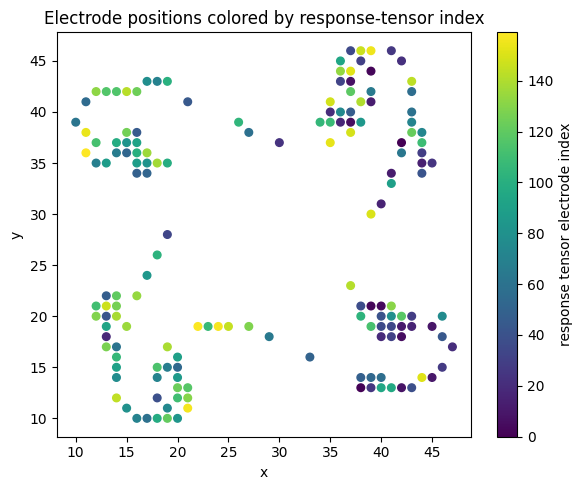

Adjacency shape: (160, 160) row sum range: 0.9999999 1.0000001


In [6]:
# ===== notebook cell 7 =====
# ============================================================
# 5. Electrode coordinates and kNN graph
# ============================================================
def try_extract_electrode_xy(impedance_map, electrodes):
    """
    Robust coordinate extraction for this course dataset.

    Why this is needed:
    - In this dataset `electrodes` is usually a vector of electrode IDs, not xy coordinates.
    - `impedance_map` is not guaranteed to be an ID image where `impedance_map[y,x] == electrode_id`.
    - The course plotting helper `map_colour_to_electrode(...)` can recover the actual plotted
      electrode locations. The previous model notebook did not use this fallback, so it silently
      fell back to a fake 1D index coordinate.

    Returns:
        coords: np.ndarray with shape [N,2], or None if all strategies fail.
    """
    el = np.asarray(electrodes)

    # Case A: electrodes already contains coordinates.
    # Try common column choices. The previous version used only the last two columns,
    # which is brittle if the array is [id, x, y] or [x, y, ...].
    if el.ndim == 2 and el.shape[0] == N and el.shape[1] >= 2:
        candidate_slices = [(0, 2)]
        if el.shape[1] >= 3:
            candidate_slices += [(1, 3), (el.shape[1] - 2, el.shape[1])]
        for a, b in candidate_slices:
            try:
                xy = el[:, a:b].astype(float)
                if (
                    np.all(np.isfinite(xy))
                    and np.unique(xy[:, 0]).size > 2
                    and np.unique(xy[:, 1]).size > 2
                    and np.unique(xy, axis=0).shape[0] > max(5, N // 4)
                ):
                    return xy
            except Exception:
                pass

    # Electrode IDs for lookup.
    if el.ndim == 1:
        ids = el.reshape(-1)
    elif el.ndim == 2 and el.shape[0] == N:
        ids = el[:, 0].reshape(-1)
    else:
        ids = np.arange(N)

    # Case B: dict-like mapping electrode id -> xy.
    # Try before array conversion; np.asarray(dict) produces a 0D object array.
    if isinstance(impedance_map, dict):
        coords = []
        ok = True
        for eid in ids:
            keys = [eid]
            try:
                keys.append(int(eid))
            except Exception:
                pass
            keys.append(str(eid))
            found = None
            for k in keys:
                if k in impedance_map:
                    found = impedance_map[k]
                    break
            if found is None:
                ok = False
                break
            arr = np.asarray(found).astype(float).ravel()
            if arr.size < 2:
                ok = False
                break
            coords.append(arr[:2])
        if ok and len(coords) == N:
            coords = np.asarray(coords, dtype=float)
            if np.unique(coords, axis=0).shape[0] > max(5, N // 4):
                return coords

    # Case C: impedance_map is a 2D grid containing electrode IDs.
    try:
        imp = np.squeeze(np.asarray(impedance_map))
        if imp.ndim > 2:
            imp = imp[..., 0]
        if imp.ndim == 2:
            coords = []
            ok = True
            for eid in ids:
                loc = np.argwhere(imp == eid)
                if loc.size == 0:
                    try:
                        loc = np.argwhere(imp == int(eid))
                    except Exception:
                        pass
                if loc.size == 0:
                    ok = False
                    break
                y, x = loc[0]
                coords.append([float(x), float(y)])
            if ok and len(coords) == N:
                coords = np.asarray(coords, dtype=float)
                if np.unique(coords, axis=0).shape[0] > max(5, N // 4):
                    return coords
    except Exception:
        pass

    # Case D: course plotting-helper fallback.
    # This was the missing piece. The audit notebook had it; this model notebook did not.
    if map_colour_to_electrode is None:
        print("map_colour_to_electrode is unavailable; cannot use plotting-helper coordinate extraction.")
        return None
    try:
        fig, ax = plt.subplots(figsize=(4, 4))
        map_colour_to_electrode(ax, impedance_map, electrodes)
        coords = None
        for collection in ax.collections:
            offsets = np.asarray(collection.get_offsets())
            if offsets.ndim == 2 and offsets.shape[0] == N and offsets.shape[1] >= 2:
                candidate = offsets[:, :2].astype(float)
                if (
                    np.all(np.isfinite(candidate))
                    and np.unique(candidate[:, 0]).size > 2
                    and np.unique(candidate[:, 1]).size > 2
                    and np.unique(candidate, axis=0).shape[0] > max(5, N // 4)
                ):
                    coords = candidate
                    break
        plt.close(fig)
        if coords is not None:
            return coords
    except Exception as e:
        try:
            plt.close(fig)
        except Exception:
            pass
        print("Plotting-helper coordinate extraction failed:", repr(e))

    return None

coords = try_extract_electrode_xy(impedance_map, electrodes)
if coords is None:
    msg = (
        "Could not extract physical electrode coordinates. "
        "Stopping instead of falling back to fake 1D coordinates, because that would make the graph ablation invalid."
    )
    if REQUIRE_PHYSICAL_COORDS:
        raise RuntimeError(msg)
    print("WARNING:", msg, "Using fake 1D coordinates only because REQUIRE_PHYSICAL_COORDS=False.")
    coords = np.stack([np.arange(N), np.zeros(N)], axis=1).astype(np.float32)
else:
    coords = coords.astype(np.float32)

# Fail fast if extraction returned a degenerate line or duplicate coordinates.
if REQUIRE_PHYSICAL_COORDS:
    if coords.ndim != 2 or coords.shape != (N, 2):
        raise RuntimeError(f"Invalid coordinate shape {coords.shape}; expected {(N, 2)}")
    if np.unique(coords, axis=0).shape[0] < max(5, N // 4):
        raise RuntimeError("Coordinate extraction produced too few unique positions; graph would be invalid.")
    if np.std(coords[:, 0]) < 1e-6 or np.std(coords[:, 1]) < 1e-6:
        raise RuntimeError("Coordinate extraction produced a degenerate 1D line; graph would be invalid.")

print("Coordinate ranges:", (float(coords[:,0].min()), float(coords[:,0].max())), (float(coords[:,1].min()), float(coords[:,1].max())))

coord_mean = coords.mean(axis=0, keepdims=True)
coord_std = coords.std(axis=0, keepdims=True) + 1e-6
coords_norm = (coords - coord_mean) / coord_std

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=np.arange(N), s=30)
plt.colorbar(label="response tensor electrode index")
plt.title("Electrode positions colored by response-tensor index")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


def build_knn_adjacency(coords_norm, k=8, self_weight=1.0):
    C = np.asarray(coords_norm, dtype=np.float32)
    d = ((C[:, None, :] - C[None, :, :]) ** 2).sum(axis=-1) ** 0.5
    A = np.zeros((len(C), len(C)), dtype=np.float32)
    for i in range(len(C)):
        nn_idx = np.argsort(d[i])[1:k+1]
        scale = np.median(d[i, nn_idx]) + 1e-6
        weights = np.exp(-d[i, nn_idx] / scale)
        A[i, nn_idx] = weights
    A = np.maximum(A, A.T)
    A += np.eye(len(C), dtype=np.float32) * self_weight
    A = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    return A

adjacency = build_knn_adjacency(coords_norm, k=BASE_MODEL_CONFIG["graph_k"])
identity_adjacency = np.eye(N, dtype=np.float32)
print("Adjacency shape:", adjacency.shape, "row sum range:", adjacency.sum(axis=1).min(), adjacency.sum(axis=1).max())


In [7]:
# ===== notebook cell 8 =====
# ============================================================
# 6. Train/validation split
# ============================================================
def make_split(mode="random", val_frac=0.1, seed=None):
    rng = np.random.default_rng(seed)
    idx = np.arange(M)
    if mode == "random":
        rng.shuffle(idx)
        n_val = int(round(M * val_frac))
        return idx[n_val:], idx[:n_val]

    if mode == "blocked_time":
        n_val = int(round(M * val_frac))
        return idx[:-n_val], idx[-n_val:]

    if mode == "leave_frequency_out":
        unique_f = np.sort(np.unique(freqs))
        rng.shuffle(unique_f)
        n_val_f = max(1, int(round(len(unique_f) * val_frac)))
        val_freqs = set(unique_f[:n_val_f].tolist())
        val_mask = np.array([f in val_freqs for f in freqs])
        return idx[~val_mask], idx[val_mask]

    if mode == "leave_pattern_out":
        unique_p = np.sort(np.unique(patterns))
        rng.shuffle(unique_p)
        n_val_p = max(1, int(round(len(unique_p) * val_frac)))
        val_patterns = set(unique_p[:n_val_p].tolist())
        val_mask = np.array([int(p) in val_patterns for p in patterns])
        return idx[~val_mask], idx[val_mask]

    raise ValueError(f"Unknown split mode: {mode}")


def set_active_split(seed=None):
    global train_idx, val_idx, CURRENT_SPLIT_SEED
    CURRENT_SPLIT_SEED = seed
    train_idx, val_idx = make_split(SPLIT_MODE, VAL_FRAC, seed)
    if seed is None:
        print("Random validation split: fresh unseeded draw")
    else:
        print("Random validation split seed:", seed)
    print("Train trials:", len(train_idx), "Val trials:", len(val_idx))
    print("Train unique freqs:", len(np.unique(freqs[train_idx])), "Val unique freqs:", len(np.unique(freqs[val_idx])))
    print("Train unique patterns:", np.unique(patterns[train_idx]).tolist())
    print("Val unique patterns:", np.unique(patterns[val_idx]).tolist())
    print("Train pattern counts:", np.bincount(patterns[train_idx], minlength=n_patterns)[:n_patterns])
    print("Val pattern counts:", np.bincount(patterns[val_idx], minlength=n_patterns)[:n_patterns])
    return train_idx, val_idx

train_idx, val_idx = set_active_split(RANDOM_SEED)


Random validation split: fresh unseeded draw
Train trials: 26730 Val trials: 8910
Train unique freqs: 79 Val unique freqs: 79
Train unique patterns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Val unique patterns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Train pattern counts: [1735 1629 1650 1650 1658 1671 1669 1727 1667 1606 1662 1682 1713 1630
 1717 1664]
Val pattern counts: [573 552 550 548 575 568 556 583 554 489 561 532 583 547 558 581]


In [8]:
# ===== notebook cell 9 =====
# ============================================================
# 7. Baseline logits
# ============================================================
def compute_baseline_logits(X_train, patterns_train, n_patterns, alpha=25.0, eps=1e-5):
    global_p = X_train.mean(axis=0).astype(np.float32)
    baseline_p = np.zeros((n_patterns, X_train.shape[1], X_train.shape[2]), dtype=np.float32)
    for p in range(n_patterns):
        mask = patterns_train == p
        if mask.sum() == 0:
            baseline_p[p] = global_p
        else:
            n = int(mask.sum())
            baseline_p[p] = (X_train[mask].sum(axis=0) + alpha * global_p) / (n + alpha)
    return np_logit(baseline_p, eps=eps).astype(np.float32), global_p.astype(np.float32)

pattern_baseline_logits, global_p = compute_baseline_logits(
    X[train_idx], patterns[train_idx], n_patterns,
    alpha=BASE_MODEL_CONFIG["pattern_baseline_alpha"]
)
global_baseline_logits = np_logit(global_p)[None, :, :].repeat(n_patterns, axis=0).astype(np.float32)


def eval_pattern_baseline(idx, name):
    probs = 1 / (1 + np.exp(-pattern_baseline_logits[patterns[idx]]))
    bce = bce_from_prob_np(X[idx], probs)
    global_bce = bce_from_prob_np(X[idx], np.broadcast_to(global_p, X[idx].shape))
    print(f"{name}: global BCE={global_bce:.6f}, pattern-smoothed BCE={bce:.6f}, improvement={(global_bce-bce)/global_bce*100:.2f}%")
    return global_bce, bce

train_global_bce, train_pattern_bce = eval_pattern_baseline(train_idx, "train")
val_global_bce, val_pattern_bce = eval_pattern_baseline(val_idx, "val")


train: global BCE=0.038195, pattern-smoothed BCE=0.035730, improvement=6.45%
val: global BCE=0.038003, pattern-smoothed BCE=0.036068, improvement=5.09%


In [9]:
# ===== notebook cell 10 =====
# ============================================================
# 8. Deployable context features: previous z, z-window summaries, predicted-history placeholders
# ============================================================
def build_prev_z_features(freqs_arr, patterns_arr, stim_times_arr=None):
    """Causal features using only previous stimulation parameters."""
    f = np.asarray(freqs_arr, dtype=np.float32).reshape(-1)
    p = np.asarray(patterns_arr, dtype=np.int64).reshape(-1)
    prev_f = np.empty_like(f)
    prev_p = np.empty_like(p)
    prev_f[0] = f[0]
    prev_p[0] = p[0]
    prev_f[1:] = f[:-1]
    prev_p[1:] = p[:-1]

    if stim_times_arr is not None:
        st = np.asarray(stim_times_arr, dtype=np.float32).reshape(-1)
        if len(st) == len(f):
            dt = np.empty_like(f, dtype=np.float32)
            dt[0] = np.median(np.diff(st)) if len(st) > 1 else 0.0
            dt[1:] = np.diff(st)
        else:
            dt = np.ones_like(f, dtype=np.float32)
    else:
        dt = np.ones_like(f, dtype=np.float32)

    rolling_prev_f3 = np.zeros_like(f, dtype=np.float32)
    for i in range(len(f)):
        lo = max(0, i - 3)
        rolling_prev_f3[i] = f[lo:i].mean() if i > lo else f[i]
    freq_delta = f - prev_f
    feats = np.stack([prev_f, dt, rolling_prev_f3, freq_delta], axis=1).astype(np.float32)
    names = ["prev_freq", "delta_t", "rolling_prev_freq3", "freq_delta"]
    return prev_p.astype(np.int64), feats, names


def build_z_window_summary_features(freqs_arr, patterns_arr, n_patterns, windows=(3, 5, 10, 20)):
    """Causal hand-crafted features from previous stimulation schedule only."""
    f = np.asarray(freqs_arr, dtype=np.float32).reshape(-1)
    p = np.asarray(patterns_arr, dtype=np.int64).reshape(-1)
    Mloc = len(f)
    rows = []
    names = []
    for i in range(Mloc):
        vals = []
        for w in windows:
            lo = max(0, i - w)
            pf = f[lo:i]
            pp = p[lo:i]
            if len(pf) == 0:
                pf = f[i:i+1]
                pp = p[i:i+1]
            vals.extend([
                float(pf.mean()),
                float(pf.std()) if len(pf) > 1 else 0.0,
                float(pf[-1]),
                float(f[i] - pf[-1]),
                float(len(np.unique(pp)) / max(1, min(w, n_patterns))),
                float(np.mean(pp == p[i])),
            ])
        rows.append(vals)
    for w in windows:
        names.extend([
            f"zwin{w}_freq_mean",
            f"zwin{w}_freq_std",
            f"zwin{w}_last_freq",
            f"zwin{w}_current_minus_last_freq",
            f"zwin{w}_pattern_diversity",
            f"zwin{w}_same_current_pattern_frac",
        ])
    return np.asarray(rows, dtype=np.float32), names


def build_z_history_sequences(freqs_arr, patterns_arr, stim_times_arr=None, history_len=24):
    """Return previous-z token sequence for each trial. No current trial included."""
    f = np.asarray(freqs_arr, dtype=np.float32).reshape(-1)
    p = np.asarray(patterns_arr, dtype=np.int64).reshape(-1)
    Mloc = len(f)
    hist_p = np.zeros((Mloc, history_len), dtype=np.int64)
    hist_cont = np.zeros((Mloc, history_len, 3), dtype=np.float32)
    f_min = float(np.min(f)); f_max = float(np.max(f))
    denom = f_max - f_min + 1e-6

    if stim_times_arr is not None:
        st = np.asarray(stim_times_arr, dtype=np.float32).reshape(-1)
        if len(st) == len(f):
            dt_all = np.empty_like(f, dtype=np.float32)
            dt_all[0] = np.median(np.diff(st)) if len(st) > 1 else 0.0
            dt_all[1:] = np.diff(st)
        else:
            dt_all = np.ones_like(f, dtype=np.float32)
    else:
        dt_all = np.ones_like(f, dtype=np.float32)
    dt_scale = np.percentile(dt_all[1:], 95) if len(dt_all) > 1 else 1.0
    dt_scale = max(float(dt_scale), 1e-6)

    for i in range(Mloc):
        for k in range(history_len):
            j = i - history_len + k
            if j < 0:
                jj = 0
                valid = 0.0
            else:
                jj = j
                valid = 1.0
            hist_p[i, k] = int(p[jj])
            f_norm = (float(f[jj]) - f_min) / denom
            dt_norm = float(dt_all[jj]) / dt_scale
            age_norm = (history_len - k) / history_len
            hist_cont[i, k] = [f_norm, dt_norm, age_norm * valid]
    hist_cont = np.nan_to_num(hist_cont, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return hist_p, hist_cont


def standardize_context(train_context, full_context):
    train_context = np.asarray(train_context, dtype=np.float32)
    full_context = np.asarray(full_context, dtype=np.float32)
    mean = train_context.mean(axis=0, keepdims=True)
    std = train_context.std(axis=0, keepdims=True) + 1e-6
    norm = (full_context - mean) / std
    norm = np.nan_to_num(norm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return norm, mean.astype(np.float32), std.astype(np.float32)


prev_patterns, prevz_raw, prevz_names = build_prev_z_features(freqs, patterns, stimulation_times)
zsummary_raw, zsummary_names = build_z_window_summary_features(freqs, patterns, n_patterns)
hist_patterns, hist_cont = build_z_history_sequences(freqs, patterns, stimulation_times, history_len=MAX_Z_HISTORY_LEN)

zsummary_full_raw = np.concatenate([prevz_raw, zsummary_raw], axis=1)
zsummary_all_names = prevz_names + zsummary_names
nonfreq_context_cols = [i for i, nm in enumerate(zsummary_all_names) if "freq" not in nm]
freq_context_cols = [i for i, nm in enumerate(zsummary_all_names) if "freq" in nm]
zsummary_nofreq_raw = zsummary_full_raw[:, nonfreq_context_cols]
zsummary_freq_raw = zsummary_full_raw[:, freq_context_cols]


def build_contexts_for_train(train_indices):
    train_indices = np.asarray(train_indices, dtype=int)
    contexts = {}
    prevz_norm, prevz_mean, prevz_std = standardize_context(prevz_raw[train_indices], prevz_raw)
    contexts["prevz_only"] = dict(raw=prevz_raw, norm=prevz_norm, mean=prevz_mean, std=prevz_std, names=prevz_names)

    zsummary_norm, zsummary_mean, zsummary_std = standardize_context(zsummary_full_raw[train_indices], zsummary_full_raw)
    contexts["z_window_summary"] = dict(
        raw=zsummary_full_raw, norm=zsummary_norm, mean=zsummary_mean, std=zsummary_std,
        names=prevz_names + zsummary_names,
    )

    zsummary_nofreq_norm, zsummary_nofreq_mean, zsummary_nofreq_std = standardize_context(zsummary_nofreq_raw[train_indices], zsummary_nofreq_raw)
    contexts["z_window_no_frequency_context"] = dict(
        raw=zsummary_nofreq_raw, norm=zsummary_nofreq_norm, mean=zsummary_nofreq_mean, std=zsummary_nofreq_std,
        names=[zsummary_all_names[i] for i in nonfreq_context_cols],
    )

    zsummary_freq_norm, zsummary_freq_mean, zsummary_freq_std = standardize_context(zsummary_freq_raw[train_indices], zsummary_freq_raw)
    contexts["z_window_frequency_context"] = dict(
        raw=zsummary_freq_raw, norm=zsummary_freq_norm, mean=zsummary_freq_mean, std=zsummary_freq_std,
        names=[zsummary_all_names[i] for i in freq_context_cols],
    )
    return contexts


CONTEXTS = build_contexts_for_train(train_idx)
print("Available initial contexts:")
for k, v in CONTEXTS.items():
    print(f"  {k}: dim={v['norm'].shape[1]}")
print("z-GRU history arrays:", hist_patterns.shape, hist_cont.shape)


Available initial contexts:
  prevz_only: dim=4
  z_window_summary: dim=28
  z_window_no_frequency_context: dim=9
  z_window_frequency_context: dim=19
z-GRU history arrays: (35640, 24) (35640, 24, 3)


In [10]:
# ===== notebook cell 11 =====
# ============================================================
# 9. Dataset and DataLoaders
# ============================================================
_BASE_TENSORS = {}


def get_base_tensors():
    """Cache immutable CPU tensors once per worker process."""
    if not _BASE_TENSORS:
        _BASE_TENSORS.update(
            X=torch.as_tensor(X, dtype=torch.float32),
            patterns=torch.as_tensor(patterns, dtype=torch.long),
            freqs=torch.as_tensor(freqs, dtype=torch.float32),
            prev_patterns=torch.as_tensor(prev_patterns, dtype=torch.long),
            hist_patterns=torch.as_tensor(hist_patterns, dtype=torch.long),
            hist_cont=torch.as_tensor(hist_cont, dtype=torch.float32),
        )
    return _BASE_TENSORS


class Task2Dataset(Dataset):
    def __init__(self, indices, cont_context, history_len=Z_HISTORY_LEN):
        base = get_base_tensors()
        self.indices = torch.as_tensor(np.asarray(indices), dtype=torch.long)
        self.X = base["X"]
        self.patterns = base["patterns"]
        self.freqs = base["freqs"]
        self.prev_patterns = base["prev_patterns"]
        self.cont_context = torch.as_tensor(cont_context, dtype=torch.float32)
        self.hist_patterns = base["hist_patterns"]
        self.hist_cont = base["hist_cont"]
        self.history_len = int(history_len)
        if self.history_len < 1 or self.history_len > self.hist_patterns.shape[1]:
            raise ValueError(f"history_len must be in [1, {self.hist_patterns.shape[1]}], got {self.history_len}")

    def __len__(self):
        return int(self.indices.numel())

    def __getitem__(self, j):
        i = self.indices[j]
        return {
            "trial_index": i,
            "pattern": self.patterns[i],
            "freq": self.freqs[i],
            "prev_pattern": self.prev_patterns[i],
            "context": self.cont_context[i],
            "hist_patterns": self.hist_patterns[i, -self.history_len:],
            "hist_cont": self.hist_cont[i, -self.history_len:, :],
            "x": self.X[i],
        }


def make_loader(indices, context_array, shuffle=False, batch_size=BATCH_SIZE, history_len=Z_HISTORY_LEN):
    ds = Task2Dataset(indices, context_array, history_len=history_len)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
        persistent_workers=(NUM_WORKERS > 0),
    )

# Sanity check with prevz context and default history length.
batch = next(iter(make_loader(train_idx[:min(8, len(train_idx))], CONTEXTS["prevz_only"]["norm"], shuffle=False, batch_size=8, history_len=Z_HISTORY_LEN)))
for k, v in batch.items():
    print(k, tuple(v.shape), v.dtype)


trial_index (8,) torch.int64
pattern (8,) torch.int64
freq (8,) torch.float32
prev_pattern (8,) torch.int64
context (8, 4) torch.float32
hist_patterns (8, 24) torch.int64
hist_cont (8, 24, 3) torch.float32
x (8, 160, 80) torch.float32


In [11]:
# ===== notebook cell 12 =====
# ============================================================
# 10. Model: C2 residual decoder + deployable z-history mechanisms
# ============================================================
class FrequencyEncoder(nn.Module):
    def __init__(self, f_min, f_max, n_rbf=16, use_rbf=True):
        super().__init__()
        self.use_rbf = bool(use_rbf and n_rbf > 0)
        self.n_rbf = int(n_rbf) if self.use_rbf else 0
        self.register_buffer("f_min", torch.tensor(float(f_min)))
        self.register_buffer("f_max", torch.tensor(float(f_max)))
        if self.use_rbf:
            log_min = math.log(max(float(f_min), 1e-4))
            log_max = math.log(max(float(f_max), 1e-4))
            centers = torch.linspace(log_min, log_max, self.n_rbf)
            self.register_buffer("centers", centers)
            width = float((centers[1] - centers[0]).abs()) if self.n_rbf > 1 else 1.0
            self.log_width = nn.Parameter(torch.tensor(math.log(width + 1e-6)), requires_grad=False)
        else:
            self.register_buffer("centers", torch.zeros(0))
            self.log_width = nn.Parameter(torch.tensor(0.0), requires_grad=False)

    @property
    def out_dim(self):
        return 2 + 8 + self.n_rbf

    def forward(self, f):
        f = f.float().clamp_min(1e-4)
        f_norm = (f - self.f_min) / (self.f_max - self.f_min + 1e-6)
        lf = torch.log(f)
        lf_min = torch.log(self.f_min.clamp_min(1e-4))
        lf_max = torch.log(self.f_max.clamp_min(1e-4))
        lf_norm = (lf - lf_min) / (lf_max - lf_min + 1e-6)
        fourier = []
        for k in [1.0, 2.0, 4.0, 8.0]:
            fourier.append(torch.sin(2 * math.pi * k * lf_norm))
            fourier.append(torch.cos(2 * math.pi * k * lf_norm))
        fourier = torch.stack(fourier, dim=-1)
        pieces = [f_norm[:, None], lf_norm[:, None], fourier]
        if self.use_rbf:
            width = torch.exp(self.log_width)
            rbf = torch.exp(-0.5 * ((lf[:, None] - self.centers[None, :]) / (width + 1e-6)) ** 2)
            pieces.append(rbf)
        return torch.cat(pieces, dim=-1)


class ZHistoryEncoder(nn.Module):
    """GRU over previous stimulation tokens only. Fully deployable."""
    def __init__(self, n_patterns, pattern_dim=16, cont_dim=3, hidden_dim=48, layers=1, dropout=0.0, pattern_mode="embedding"):
        super().__init__()
        self.pattern_mode = str(pattern_mode)
        if self.pattern_mode == "embedding":
            self.pattern_emb = nn.Embedding(n_patterns, pattern_dim)
            pattern_in_dim = pattern_dim
        elif self.pattern_mode == "bits":
            self.pattern_emb = None
            pattern_in_dim = 4
        elif self.pattern_mode == "none":
            self.pattern_emb = None
            pattern_in_dim = 0
        else:
            raise ValueError(f"Unknown z-history pattern_mode: {pattern_mode}")
        self.step_mlp = nn.Sequential(
            nn.Linear(pattern_in_dim + cont_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        )
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.out_dim = hidden_dim

    @staticmethod
    def pattern_bits(pattern):
        return torch.stack([((pattern >> b) & 1).float() for b in range(4)], dim=-1)

    def forward(self, hist_patterns, hist_cont):
        # hist_patterns: [B,L], hist_cont: [B,L,C]
        if self.pattern_mode == "embedding":
            pat = self.pattern_emb(hist_patterns.clamp_min(0))
            x = torch.cat([pat, hist_cont.float()], dim=-1)
        elif self.pattern_mode == "bits":
            pat = self.pattern_bits(hist_patterns.clamp_min(0))
            x = torch.cat([pat, hist_cont.float()], dim=-1)
        else:
            x = hist_cont.float()
        x = self.step_mlp(x)
        _, h = self.gru(x)
        return h[-1]

class GraphBlock(nn.Module):
    def __init__(self, hidden_dim, cond_dim, dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + cond_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, cond, adj):
        m = torch.einsum("ij,bjh->bih", adj, h)
        c = cond[:, None, :].expand(-1, h.shape[1], -1)
        upd = self.mlp(torch.cat([h, m, c], dim=-1))
        return self.norm(h + self.dropout(upd))


class CoordGraphTemporalResidualDecoder(nn.Module):
    def __init__(self, n_patterns, n_electrodes, n_time, coords_norm, adjacency, pattern_baseline_logits,
                 f_min, f_max, config):
        super().__init__()
        self.n_patterns = n_patterns
        self.n_electrodes = n_electrodes
        self.n_time = n_time
        self.config = dict(config)

        self.register_buffer("coords", torch.as_tensor(coords_norm, dtype=torch.float32))
        self.register_buffer("adj", torch.as_tensor(adjacency, dtype=torch.float32))
        self.register_buffer("pattern_baseline_logits", torch.as_tensor(pattern_baseline_logits, dtype=torch.float32))

        pattern_emb_dim = int(config["pattern_emb_dim"])
        bit_emb_dim = int(config["bit_emb_dim"])
        electrode_emb_dim = int(config["electrode_emb_dim"])
        cond_dim = int(config["cond_dim"])
        hidden_dim = int(config["hidden_dim"])
        k_modes = int(config["k_modes"])
        dropout = float(config["dropout"])

        self.use_pattern_embedding = bool(config.get("use_pattern_embedding", True))
        self.use_bit_features = bool(config.get("use_bit_features", True))
        self.current_bit_feature_mode = str(config.get("current_bit_feature_mode", "single"))
        self.current_bit_encoder = str(config.get("current_bit_encoder", "mlp"))
        self.use_frequency_features = bool(config.get("use_frequency_features", True))
        self.use_frequency_film = bool(config.get("use_frequency_film", False))
        self.use_prev_z_context = bool(config.get("use_prev_z_context", True))
        self.use_prev_pattern_context = bool(config.get("use_prev_pattern_context", True))
        self.use_prev_pattern_bit_context = bool(config.get("use_prev_pattern_bit_context", False))
        self.use_cont_context = bool(config.get("use_cont_context", True))
        self.use_z_gru_state = bool(config.get("use_z_gru_state", False))
        self.use_coordinates = bool(config.get("use_coordinates", True))
        self.use_electrode_embedding = bool(config.get("use_electrode_embedding", True))
        self.use_electrode_rate = bool(config.get("use_electrode_rate", True))
        self.use_graph = bool(config.get("use_graph", True))
        self.use_cond_time_bias = bool(config.get("use_cond_time_bias", True))
        if self.use_pattern_embedding:
            self.pattern_emb = nn.Embedding(n_patterns, pattern_emb_dim)
            pattern_cond_dim = pattern_emb_dim
        else:
            self.pattern_emb = None
            pattern_cond_dim = 0

        if self.use_prev_z_context and self.use_prev_pattern_context:
            self.prev_pattern_emb = nn.Embedding(n_patterns, max(1, pattern_emb_dim // 2))
            self.prev_pattern_bit_mlp = None
            prev_pattern_dim = max(1, pattern_emb_dim // 2)
        elif self.use_prev_z_context and self.use_prev_pattern_bit_context:
            self.prev_pattern_emb = None
            self.prev_pattern_bit_mlp = nn.Sequential(nn.Linear(4, bit_emb_dim), nn.GELU(), nn.Linear(bit_emb_dim, bit_emb_dim))
            prev_pattern_dim = bit_emb_dim
        else:
            self.prev_pattern_emb = None
            self.prev_pattern_bit_mlp = None
            prev_pattern_dim = 0

        if self.use_bit_features:
            if self.current_bit_feature_mode != "single" or self.current_bit_encoder != "linear":
                raise ValueError("Cleaned C4 baseline only supports four raw current bits with a linear projection.")
            self.bit_mlp = nn.Linear(4, bit_emb_dim)
            bit_cond_dim = bit_emb_dim
        else:
            self.bit_mlp = None
            bit_cond_dim = 0

        if self.use_frequency_features:
            self.freq_enc = FrequencyEncoder(f_min, f_max, n_rbf=config["freq_rbf_dim"], use_rbf=config.get("use_rbf_features", True))
            freq_cond_dim = self.freq_enc.out_dim
        else:
            self.freq_enc = None
            freq_cond_dim = 0


        self.context_dim = int(config.get("context_dim", 4)) if (self.use_prev_z_context and self.use_cont_context) else 0
        context_dim = self.context_dim

        if self.use_z_gru_state:
            self.z_hist_enc = ZHistoryEncoder(
                n_patterns=n_patterns,
                pattern_dim=max(8, pattern_emb_dim // 2),
                cont_dim=3,
                hidden_dim=int(config.get("z_gru_hidden_dim", 48)),
                layers=int(config.get("z_gru_layers", 1)),
                dropout=dropout,
                pattern_mode=config.get("z_history_pattern_mode", "embedding"),
            )
            z_state_dim = self.z_hist_enc.out_dim
        else:
            self.z_hist_enc = None
            z_state_dim = 0

        cond_in = pattern_cond_dim + bit_cond_dim + freq_cond_dim + prev_pattern_dim + context_dim + z_state_dim
        if cond_in <= 0:
            cond_in = 1
            self.cond_dummy = True
        else:
            self.cond_dummy = False

        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_in, cond_dim * 2),
            nn.LayerNorm(cond_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(cond_dim * 2, cond_dim),
            nn.LayerNorm(cond_dim),
            nn.GELU(),
        )
        if self.use_frequency_film and self.use_frequency_features:
            self.freq_film = nn.Sequential(
                nn.Linear(freq_cond_dim, cond_dim * 2),
                nn.GELU(),
                nn.Linear(cond_dim * 2, cond_dim * 2),
            )
            nn.init.zeros_(self.freq_film[-1].weight)
            nn.init.zeros_(self.freq_film[-1].bias)
        else:
            self.freq_film = None

        if self.use_electrode_embedding:
            self.electrode_emb = nn.Embedding(n_electrodes, electrode_emb_dim)
            elec_emb_dim_used = electrode_emb_dim
        else:
            self.electrode_emb = None
            elec_emb_dim_used = 0

        coord_dim = 2 if self.use_coordinates else 0
        erate_dim = 1 if self.use_electrode_rate else 0
        elec_feat_dim = coord_dim + 1 + erate_dim + elec_emb_dim_used + cond_dim
        self.electrode_in = nn.Sequential(
            nn.Linear(elec_feat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

        n_graph_layers = int(config["n_graph_layers"]) if self.use_graph else 0
        self.graph_blocks = nn.ModuleList([GraphBlock(hidden_dim, cond_dim, dropout=dropout) for _ in range(n_graph_layers)])

        self.time_emb = nn.Embedding(n_time, max(4, hidden_dim // 2))
        self.time_mlp = nn.Sequential(
            nn.Linear(max(4, hidden_dim // 2) + 4, k_modes),
            nn.GELU(),
            nn.Linear(k_modes, k_modes),
        )
        self.coeff_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, k_modes),
        )
        self.spatial_bias = nn.Linear(hidden_dim, 1)
        self.cond_time_bias = nn.Sequential(nn.Linear(cond_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, n_time))

        nn.init.normal_(self.coeff_head[-1].weight, mean=0.0, std=1e-4)
        nn.init.zeros_(self.coeff_head[-1].bias)
        nn.init.zeros_(self.spatial_bias.weight)
        nn.init.zeros_(self.spatial_bias.bias)
        nn.init.zeros_(self.cond_time_bias[-1].weight)
        nn.init.zeros_(self.cond_time_bias[-1].bias)
        self.residual_scale = nn.Parameter(torch.tensor(0.2))

        with torch.no_grad():
            p = torch.sigmoid(self.pattern_baseline_logits.float())
            electrode_rate = p.mean(dim=(0, 2))
            electrode_rate = (electrode_rate - electrode_rate.mean()) / (electrode_rate.std() + 1e-6)
            self.register_buffer("electrode_rate", electrode_rate.float())
            idx = torch.linspace(-1, 1, n_electrodes)
            self.register_buffer("electrode_index_norm", idx.float())

    def pattern_bits(self, pattern):
        return torch.stack([((pattern >> b) & 1).float() for b in range(4)], dim=-1)

    def current_bit_features(self, pattern):
        return self.pattern_bits(pattern)

    def condition_vector(self, pattern, freq, prev_pattern=None, context=None, hist_patterns=None, hist_cont=None):
        pieces = []
        pattern_vec = self.pattern_emb(pattern) if self.use_pattern_embedding else None
        freq_vec = self.freq_enc(freq) if self.use_frequency_features else None
        if pattern_vec is not None:
            pieces.append(pattern_vec)
        if self.use_bit_features:
            pieces.append(self.bit_mlp(self.current_bit_features(pattern)))
        if freq_vec is not None:
            pieces.append(freq_vec)
        if self.use_prev_z_context and (self.use_prev_pattern_context or self.use_prev_pattern_bit_context):
            if prev_pattern is None:
                prev_pattern = pattern
            prev_pattern = prev_pattern.clamp(0, self.n_patterns - 1)
            if self.prev_pattern_emb is not None:
                pieces.append(self.prev_pattern_emb(prev_pattern))
            elif self.prev_pattern_bit_mlp is not None:
                pieces.append(self.prev_pattern_bit_mlp(self.pattern_bits(prev_pattern)))
        if self.use_prev_z_context and self.use_cont_context:
            if context is None:
                context = torch.zeros(pattern.shape[0], self.context_dim, device=pattern.device)
            pieces.append(context.float())
        if self.use_z_gru_state:
            if hist_patterns is None or hist_cont is None:
                raise ValueError("hist_patterns and hist_cont are required when use_z_gru_state=True")
            pieces.append(self.z_hist_enc(hist_patterns, hist_cont))
        if len(pieces) == 0:
            pieces = [torch.ones(pattern.shape[0], 1, device=pattern.device)]
        cond = self.cond_mlp(torch.cat(pieces, dim=-1))
        if self.freq_film is not None and freq_vec is not None:
            gamma, beta = self.freq_film(freq_vec).chunk(2, dim=-1)
            cond = cond * (1.0 + 0.1 * torch.tanh(gamma)) + 0.1 * beta
        return cond

    def forward(self, pattern, freq, prev_pattern=None, context=None, hist_patterns=None, hist_cont=None):
        B = pattern.shape[0]
        pattern = pattern.clamp(0, self.n_patterns - 1)
        cond = self.condition_vector(pattern, freq, prev_pattern, context, hist_patterns, hist_cont)

        ids = torch.arange(self.n_electrodes, device=pattern.device)
        parts = []
        if self.use_coordinates:
            parts.append(self.coords[None, :, :].expand(B, -1, -1))
        parts.append(self.electrode_index_norm[None, :, None].expand(B, -1, -1))
        if self.use_electrode_rate:
            parts.append(self.electrode_rate[None, :, None].expand(B, -1, -1))
        if self.use_electrode_embedding:
            parts.append(self.electrode_emb(ids)[None, :, :].expand(B, -1, -1))
        parts.append(cond[:, None, :].expand(-1, self.n_electrodes, -1))

        h = self.electrode_in(torch.cat(parts, dim=-1))
        for block in self.graph_blocks:
            h = block(h, cond, self.adj)

        coeff = self.coeff_head(h)
        t_ids = torch.arange(self.n_time, device=pattern.device)
        t_norm = t_ids.float() / max(self.n_time - 1, 1)
        t_feat = torch.stack([
            t_norm,
            torch.log1p(t_ids.float()) / math.log1p(max(self.n_time - 1, 1)),
            torch.exp(-0.5 * ((t_ids.float() - 7.0) / 4.0) ** 2),
            (t_ids.float() >= 20).float(),
        ], dim=-1)
        t_in = torch.cat([self.time_emb(t_ids), t_feat], dim=-1)
        basis = self.time_mlp(t_in)
        residual = torch.einsum("bnk,tk->bnt", coeff, basis) / math.sqrt(coeff.shape[-1])
        residual = residual + self.spatial_bias(h).squeeze(-1)[:, :, None]
        if self.use_cond_time_bias:
            residual = residual + self.cond_time_bias(cond)[:, None, :]

        baseline = self.pattern_baseline_logits[pattern]
        return baseline + self.residual_scale * residual


def build_model(config, baseline_logits):
    adj = adjacency if config.get("use_graph", True) else identity_adjacency
    return CoordGraphTemporalResidualDecoder(
        n_patterns=n_patterns,
        n_electrodes=N,
        n_time=T,
        coords_norm=coords_norm,
        adjacency=adj,
        pattern_baseline_logits=baseline_logits,
        f_min=float(config.get("freq_min", freqs[train_idx].min())),
        f_max=float(config.get("freq_max", freqs[train_idx].max())),
        config=config,
    )


In [12]:
# ===== notebook cell 13 =====
# ============================================================
# 11. Training, evaluation, and prediction utilities
# ============================================================
if "DEVICE" not in globals():
    DEVICE = device if "device" in globals() else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def move_batch(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def apply_prediction_constraints(logits):
    if HARD_ZERO_TIME_BINS:
        logits = logits.clone()
        logits[:, :, HARD_ZERO_TIME_BINS] = HARD_ZERO_LOGIT
    return logits


def model_forward(model, batch_dev):
    logits = model(
        batch_dev["pattern"],
        batch_dev["freq"],
        batch_dev["prev_pattern"],
        batch_dev["context"],
        batch_dev["hist_patterns"],
        batch_dev["hist_cont"],
    )
    return apply_prediction_constraints(logits)


def _masked_distribution_kl(pred_mass, true_mass, eps=1e-8):
    """Mean KL(true || pred) over rows with at least one true event."""
    true_sum = true_mass.sum(dim=-1, keepdim=True)
    mask = true_sum.squeeze(-1) > 0
    if not torch.any(mask):
        return pred_mass.new_tensor(0.0)
    pred_sum = pred_mass.sum(dim=-1, keepdim=True)
    true_dist = true_mass[mask] / (true_sum[mask] + eps)
    pred_dist = (pred_mass[mask] + eps) / (pred_sum[mask] + eps * pred_mass.shape[-1])
    kl = true_dist * ((true_dist + eps).log() - pred_dist.log())
    return kl.sum(dim=-1).mean() / math.log(max(2, pred_mass.shape[-1]))


def _first_time_loss(pred_time_mass, true_time_mass, eps=1e-8):
    active = true_time_mass.sum(dim=-1) > 0
    if not torch.any(active):
        return pred_time_mass.new_tensor(0.0)
    true_has_spike = true_time_mass[active] > 0
    true_first = true_has_spike.float().argmax(dim=-1).float()
    pred = pred_time_mass[active]
    pred_dist = (pred + eps) / (pred.sum(dim=-1, keepdim=True) + eps * pred.shape[-1])
    t = torch.arange(pred.shape[-1], device=pred.device, dtype=pred.dtype)
    pred_expected = (pred_dist * t[None, :]).sum(dim=-1)
    return F.smooth_l1_loss(pred_expected / max(1, T - 1), true_first / max(1, T - 1))


def compute_loss(
    logits,
    x,
    count_weight=AUX_COUNT_WEIGHT,
    psth_weight=AUX_PSTH_WEIGHT,
    temporal_kl_weight=AUX_TEMPORAL_KL_WEIGHT,
    spatial_kl_weight=AUX_SPATIAL_KL_WEIGHT,
    early_temporal_kl_weight=AUX_EARLY_TEMPORAL_KL_WEIGHT,
    first_time_weight=AUX_FIRST_TIME_WEIGHT,
    early_time_window=EARLY_TIME_WINDOW,
):
    bce = torch_bce_from_logits(logits, x)
    pred_prob = torch.sigmoid(logits)

    # Match the strongest previous C4 objective: BCE is the anchor. Count/PSTH
    # are light regularizers; stronger focal/ranking terms harmed top-k capture.
    pred_count = pred_prob.sum(dim=(1, 2)) / (N * T)
    true_count = x.sum(dim=(1, 2)) / (N * T)
    count_loss = F.mse_loss(pred_count, true_count)

    pred_psth = pred_prob.mean(dim=1)
    true_psth = x.mean(dim=1)
    psth_loss = F.mse_loss(pred_psth, true_psth)

    pred_time_mass = pred_prob.sum(dim=1)
    true_time_mass = x.sum(dim=1)
    temporal_kl_loss = _masked_distribution_kl(pred_time_mass, true_time_mass)

    pred_spatial_mass = pred_prob.sum(dim=2)
    true_spatial_mass = x.sum(dim=2)
    spatial_kl_loss = _masked_distribution_kl(pred_spatial_mass, true_spatial_mass)

    a, b = tuple(early_time_window)
    a = max(0, int(a)); b = min(T, int(b))
    early_temporal_kl_loss = _masked_distribution_kl(pred_time_mass[:, a:b], true_time_mass[:, a:b]) if b > a else pred_prob.new_tensor(0.0)
    first_time_loss = _first_time_loss(pred_time_mass, true_time_mass)

    total = (
        bce
        + float(count_weight) * count_loss
        + float(psth_weight) * psth_loss
        + float(temporal_kl_weight) * temporal_kl_loss
        + float(spatial_kl_weight) * spatial_kl_loss
        + float(early_temporal_kl_weight) * early_temporal_kl_loss
        + float(first_time_weight) * first_time_loss
    )
    return total, {
        "bce": bce.detach(),
        "count_loss": count_loss.detach(),
        "psth_loss": psth_loss.detach(),
        "temporal_kl_loss": temporal_kl_loss.detach(),
        "spatial_kl_loss": spatial_kl_loss.detach(),
        "early_temporal_kl_loss": early_temporal_kl_loss.detach(),
        "first_time_loss": first_time_loss.detach(),
        "joint_kl_loss": pred_prob.new_tensor(0.0),
        "focal_loss": pred_prob.new_tensor(0.0),
        "ranking_loss": pred_prob.new_tensor(0.0),
    }


def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def maybe_wrap_model(model):
    if USE_DATA_PARALLEL and torch.cuda.is_available() and len(DATA_PARALLEL_DEVICE_IDS) >= 2:
        print("Wrapping model with DataParallel on GPUs:", DATA_PARALLEL_DEVICE_IDS)
        return nn.DataParallel(model, device_ids=DATA_PARALLEL_DEVICE_IDS, output_device=PRIMARY_CUDA_DEVICE)
    return model


def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_loader(
    model,
    loader,
    device,
    store_predictions=False,
    count_weight=AUX_COUNT_WEIGHT,
    psth_weight=AUX_PSTH_WEIGHT,
    temporal_kl_weight=AUX_TEMPORAL_KL_WEIGHT,
    spatial_kl_weight=AUX_SPATIAL_KL_WEIGHT,
    early_temporal_kl_weight=AUX_EARLY_TEMPORAL_KL_WEIGHT,
    first_time_weight=AUX_FIRST_TIME_WEIGHT,
    early_time_window=EARLY_TIME_WINDOW,
):
    model.eval()
    total_loss = 0.0
    total_bce = 0.0
    part_sums = defaultdict(float)
    total_count = 0
    preds = []
    trues = []
    trial_ids = []
    with torch.no_grad():
        for batch_raw in loader:
            batch_dev = move_batch(batch_raw, device)
            logits = model_forward(model, batch_dev)
            loss, parts = compute_loss(
                logits,
                batch_dev["x"],
                count_weight=count_weight,
                psth_weight=psth_weight,
                temporal_kl_weight=temporal_kl_weight,
                spatial_kl_weight=spatial_kl_weight,
                early_temporal_kl_weight=early_temporal_kl_weight,
                first_time_weight=first_time_weight,
                early_time_window=early_time_window,
            )
            bs = batch_dev["x"].shape[0]
            total_loss += float(loss.item()) * bs
            total_bce += float(parts["bce"].item()) * bs
            for pk, pv in parts.items():
                part_sums[pk] += float(pv.item()) * bs
            total_count += bs
            if store_predictions:
                preds.append(torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32))
                trues.append(batch_dev["x"].detach().cpu().numpy().astype(np.float32))
                trial_ids.append(batch_dev["trial_index"].detach().cpu().numpy())
    out = {"loss": total_loss / max(1, total_count), "bce": total_bce / max(1, total_count), "n": int(total_count)}
    for pk, pv in part_sums.items():
        out[pk] = pv / max(1, total_count)
    if store_predictions:
        out["pred_prob"] = np.concatenate(preds, axis=0) if preds else np.zeros((0, N, T), dtype=np.float32)
        out["true"] = np.concatenate(trues, axis=0) if trues else np.zeros((0, N, T), dtype=np.float32)
        out["trial_indices"] = np.concatenate(trial_ids, axis=0) if trial_ids else np.zeros((0,), dtype=int)
    return out


def predict_all_trials(model, context_array, batch_size=BATCH_SIZE, device=DEVICE):
    loader = make_loader(np.arange(M), context_array, shuffle=False, batch_size=batch_size)
    ev = evaluate_loader(model, loader, device, store_predictions=True)
    # restore original order, since loader is sequential but be explicit
    order = np.argsort(ev["trial_indices"])
    return ev["pred_prob"][order]


def baseline_logits_for_config(config):
    mode = config.get("baseline_mode", "global")
    if mode == "pattern":
        return pattern_baseline_logits.astype(np.float32)
    if mode == "global":
        return global_baseline_logits.astype(np.float32)
    raise ValueError(f"Unknown baseline_mode: {mode}")


def make_config(base, updates):
    cfg = dict(base)
    cfg.update(updates)
    return cfg


In [ ]:
def _clone_batch(batch):
    return {k: (v.clone() if torch.is_tensor(v) else v) for k, v in batch.items()}


def _roll_batch_tensor(x):
    if x.shape[0] <= 1:
        return x
    return torch.roll(x, shifts=1, dims=0)


def _apply_input_ablation(batch, mode, context_feature_names, train_freq_mean):
    if mode in (None, "full_model"):
        return batch
    out = _clone_batch(batch)
    if mode == "current_pattern_zero":
        out["pattern"].zero_()
    elif mode == "current_pattern_shuffle_batch":
        out["pattern"] = _roll_batch_tensor(out["pattern"])
    elif mode == "frequency_train_mean":
        out["freq"].fill_(float(train_freq_mean))
    elif mode == "frequency_shuffle_batch":
        out["freq"] = _roll_batch_tensor(out["freq"])
    elif mode == "prev_pattern_zero":
        out["prev_pattern"].zero_()
    elif mode == "context_all_zero":
        out["context"].zero_()
    elif mode == "context_frequency_zero":
        cols = [i for i, nm in enumerate(context_feature_names) if "freq" in str(nm)]
        if cols:
            out["context"][:, cols] = 0.0
    elif mode == "context_nonfrequency_zero":
        cols = [i for i, nm in enumerate(context_feature_names) if "freq" not in str(nm)]
        if cols:
            out["context"][:, cols] = 0.0
    elif mode == "context_shuffle_batch":
        out["context"] = _roll_batch_tensor(out["context"])
    elif mode == "history_patterns_zero":
        out["hist_patterns"].zero_()
    elif mode == "history_continuous_zero":
        out["hist_cont"].zero_()
    elif mode == "history_frequency_zero":
        out["hist_cont"][:, :, 0] = 0.0
    elif mode == "history_timing_zero":
        out["hist_cont"][:, :, 1:] = 0.0
    elif mode == "history_all_zero":
        out["hist_patterns"].zero_()
        out["hist_cont"].zero_()
    elif mode == "history_shuffle_batch":
        out["hist_patterns"] = _roll_batch_tensor(out["hist_patterns"])
        out["hist_cont"] = _roll_batch_tensor(out["hist_cont"])
    else:
        raise ValueError(f"Unknown input ablation mode: {mode}")
    return out


def _apply_model_ablation(model, mode):
    core = unwrap_model(model)
    backups = []
    if mode in (None, "full_model"):
        return backups
    with torch.no_grad():
        if mode == "configured_baseline_only":
            backups.append((core.residual_scale, core.residual_scale.detach().clone()))
            core.residual_scale.zero_()
        elif mode == "graph_identity_adjacency":
            backups.append((core.adj, core.adj.detach().clone()))
            core.adj.copy_(torch.eye(core.adj.shape[0], device=core.adj.device, dtype=core.adj.dtype))
        elif mode == "electrode_embedding_zero" and core.electrode_emb is not None:
            backups.append((core.electrode_emb.weight, core.electrode_emb.weight.detach().clone()))
            core.electrode_emb.weight.zero_()
        elif mode == "coordinates_zero":
            backups.append((core.coords, core.coords.detach().clone()))
            core.coords.zero_()
        elif mode == "time_embedding_zero":
            backups.append((core.time_emb.weight, core.time_emb.weight.detach().clone()))
            core.time_emb.weight.zero_()
        else:
            raise ValueError(f"Unknown or unavailable model ablation mode: {mode}")
    return backups


def _restore_model_ablation(backups):
    with torch.no_grad():
        for tensor, value in reversed(backups):
            tensor.copy_(value)


def evaluate_ablation_predictions(model, loader, device, input_mode=None, model_mode=None,
                                  context_feature_names=None, train_freq_mean=None):
    model.eval()
    preds = []
    trues = []
    trial_ids = []
    context_feature_names = list(context_feature_names or [])
    train_freq_mean = float(train_freq_mean if train_freq_mean is not None else np.mean(freqs[train_idx]))
    backups = _apply_model_ablation(model, model_mode)
    try:
        with torch.no_grad():
            for batch_raw in loader:
                batch_dev = move_batch(batch_raw, device)
                batch_dev = _apply_input_ablation(batch_dev, input_mode, context_feature_names, train_freq_mean)
                logits = model_forward(model, batch_dev)
                preds.append(torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32))
                trues.append(batch_dev["x"].detach().cpu().numpy().astype(np.float32))
                trial_ids.append(batch_dev["trial_index"].detach().cpu().numpy())
    finally:
        _restore_model_ablation(backups)
    pred_prob = np.concatenate(preds, axis=0) if preds else np.zeros((0, N, T), dtype=np.float32)
    y_true = np.concatenate(trues, axis=0) if trues else np.zeros((0, N, T), dtype=np.float32)
    ids = np.concatenate(trial_ids, axis=0) if trial_ids else np.zeros((0,), dtype=int)
    return pred_prob, y_true, ids


def summarize_prediction_quality(y_true, pred_prob):
    true_counts = y_true.sum(axis=(1, 2))
    pred_counts = pred_prob.sum(axis=(1, 2))
    return {
        "bce": bce_from_prob_np(y_true, pred_prob),
        "early_bce_t0_19": bce_from_prob_np(y_true[:, :, :20], pred_prob[:, :, :20]),
        "peak_bce_t4_15": bce_from_prob_np(y_true[:, :, 4:16], pred_prob[:, :, 4:16]),
        "late_bce_t20_end": bce_from_prob_np(y_true[:, :, 20:], pred_prob[:, :, 20:]),
        "total_count_corr": corr_safe(true_counts, pred_counts),
        "total_count_mae": float(np.mean(np.abs(true_counts - pred_counts))),
    }


def evaluate_feature_importance_suite(model, val_indices, context_array, context_feature_names,
                                      device, history_len, train_indices, batch_size=BATCH_SIZE):
    loader = make_loader(val_indices, context_array, shuffle=False, batch_size=batch_size, history_len=history_len)
    train_freq_mean = float(np.mean(freqs[train_indices]))
    specs = [
        dict(name="full_model", family="reference", input_mode="full_model", model_mode="full_model",
             question="Reference validation performance.", interpretation_hint="Use deltas versus this row."),
        dict(name="configured_baseline_only", family="residual_decoder", model_mode="configured_baseline_only",
             question="How much does the learned residual decoder add beyond the configured global baseline?",
             interpretation_hint="Large BCE increase means the neural residual head is important."),
        dict(name="current_pattern_zero", family="current_pattern", input_mode="current_pattern_zero",
             question="How much does the exact current pattern identity/bit state matter?",
             interpretation_hint="Large BCE increase means current pattern information is essential."),
        dict(name="current_pattern_shuffle_batch", family="current_pattern", input_mode="current_pattern_shuffle_batch",
             question="Does swapping current patterns break predictions?",
             interpretation_hint="Large BCE increase means the model uses pattern-specific response structure."),
        dict(name="frequency_train_mean", family="frequency", input_mode="frequency_train_mean",
             question="How much direct frequency conditioning is needed at inference?",
             interpretation_hint="Small delta means frequency is weak, redundant, or mostly captured elsewhere."),
        dict(name="frequency_shuffle_batch", family="frequency", input_mode="frequency_shuffle_batch",
             question="Does mismatching frequency to trial hurt predictions?",
             interpretation_hint="Large delta means frequency-specific conditioning is meaningful."),
        dict(name="prev_pattern_zero", family="previous_pattern_context", input_mode="prev_pattern_zero",
             question="Does the immediate previous pattern embedding contribute separately from the longer GRU history?",
             interpretation_hint="Large delta means the one-step previous pattern signal is useful."),
        dict(name="context_all_zero", family="z_window_context", input_mode="context_all_zero",
             question="How much do non-GRU z-window summary features contribute?",
             interpretation_hint="Large delta means handcrafted previous-z summaries are useful."),
        dict(name="context_frequency_zero", family="z_window_context", input_mode="context_frequency_zero",
             question="Are frequency-derived z-window context fields useful or redundant?",
             interpretation_hint="Small delta means frequency context is not adding much beyond other features."),
        dict(name="context_nonfrequency_zero", family="z_window_context", input_mode="context_nonfrequency_zero",
             question="Are non-frequency z-window fields useful?",
             interpretation_hint="Large delta points to order/history/pattern context being important."),
        dict(name="context_shuffle_batch", family="z_window_context", input_mode="context_shuffle_batch",
             question="Does assigning another trial's z-window context hurt?",
             interpretation_hint="Large delta means trial-specific context matters."),
        dict(name="history_all_zero", family="z_history_gru", input_mode="history_all_zero",
             question="How much does the learned GRU history state contribute?",
             interpretation_hint="Large delta means the z-history GRU is important."),
        dict(name="history_patterns_zero", family="z_history_gru", input_mode="history_patterns_zero",
             question="Does the GRU mainly need previous pattern tokens?",
             interpretation_hint="Large delta means previous pattern sequence matters."),
        dict(name="history_continuous_zero", family="z_history_gru", input_mode="history_continuous_zero",
             question="Does the GRU mainly need previous frequency/timing/validity values?",
             interpretation_hint="Large delta means continuous history values matter."),
        dict(name="history_frequency_zero", family="z_history_gru", input_mode="history_frequency_zero",
             question="Does previous frequency inside the GRU history matter?",
             interpretation_hint="Small delta means previous-frequency information is weak or redundant."),
        dict(name="history_timing_zero", family="z_history_gru", input_mode="history_timing_zero",
             question="Does recency/timing inside the GRU history matter?",
             interpretation_hint="Large delta means the model uses temporal order/age information."),
        dict(name="history_shuffle_batch", family="z_history_gru", input_mode="history_shuffle_batch",
             question="Does assigning another trial's GRU history hurt?",
             interpretation_hint="Large delta means trial-specific history state matters."),
        dict(name="graph_identity_adjacency", family="electrode_graph", model_mode="graph_identity_adjacency",
             question="Does neighbor message passing across electrodes matter after training?",
             interpretation_hint="Large delta means graph smoothing/neighborhood interaction is useful."),
        dict(name="electrode_embedding_zero", family="electrode_features", model_mode="electrode_embedding_zero",
             question="How much does learned electrode identity contribute beyond coordinates/rate?",
             interpretation_hint="Large delta means electrode-specific learned offsets are important."),
        dict(name="coordinates_zero", family="electrode_features", model_mode="coordinates_zero",
             question="How much do physical electrode coordinates contribute?",
             interpretation_hint="Large delta means spatial coordinate information is useful."),
        dict(name="time_embedding_zero", family="temporal_decoder", model_mode="time_embedding_zero",
             question="How much does the learned time-bin embedding contribute?",
             interpretation_hint="Large delta means learned temporal shape matters beyond fixed time features."),
    ]
    rows = []
    full_metrics = None
    for spec in specs:
        pred_prob, y_true, trial_ids = evaluate_ablation_predictions(
            model, loader, device,
            input_mode=spec.get("input_mode"),
            model_mode=spec.get("model_mode"),
            context_feature_names=context_feature_names,
            train_freq_mean=train_freq_mean,
        )
        metrics = summarize_prediction_quality(y_true, pred_prob)
        if spec["name"] == "full_model":
            full_metrics = dict(metrics)
        row = {
            "ablation": spec["name"],
            "feature_family": spec["family"],
            "question": spec["question"],
            "interpretation_hint": spec["interpretation_hint"],
            "n_trials": int(len(trial_ids)),
        }
        row.update(metrics)
        rows.append(row)
    out = pd.DataFrame(rows)
    if full_metrics is None:
        raise RuntimeError("Feature-importance suite did not produce a full_model row.")
    for col in ["bce", "early_bce_t0_19", "peak_bce_t4_15", "late_bce_t20_end", "total_count_mae"]:
        out[f"delta_{col}"] = out[col] - float(full_metrics[col])
    out["delta_bce_percent"] = out["delta_bce"] / max(float(full_metrics["bce"]), 1e-12) * 100.0
    out["importance_rank"] = out["delta_bce"].rank(method="first", ascending=False).astype(int)
    out = out.sort_values(["importance_rank", "ablation"]).reset_index(drop=True)
    return out



def compute_per_axis_bce(y_true, pred_prob, global_prob, pattern_prob):
    rows_t = []
    for t in range(y_true.shape[2]):
        rows_t.append({
            "time_bin": int(t),
            "model_bce": bce_from_prob_np(y_true[:, :, t], pred_prob[:, :, t]),
            "global_bce": bce_from_prob_np(y_true[:, :, t], global_prob[:, :, t]),
            "pattern_bce": bce_from_prob_np(y_true[:, :, t], pattern_prob[:, :, t]),
        })
    per_time = pd.DataFrame(rows_t)
    per_time["improvement_vs_pattern"] = (per_time["pattern_bce"] - per_time["model_bce"]) / per_time["pattern_bce"]

    rows_e = []
    for n in range(y_true.shape[1]):
        rows_e.append({
            "electrode": int(n),
            "model_bce": bce_from_prob_np(y_true[:, n, :], pred_prob[:, n, :]),
            "global_bce": bce_from_prob_np(y_true[:, n, :], global_prob[:, n, :]),
            "pattern_bce": bce_from_prob_np(y_true[:, n, :], pattern_prob[:, n, :]),
        })
    per_electrode = pd.DataFrame(rows_e)
    per_electrode["improvement_vs_pattern"] = (per_electrode["pattern_bce"] - per_electrode["model_bce"]) / per_electrode["pattern_bce"]
    return per_time, per_electrode


def _distribution_kl_np(true_mass, pred_mass, eps=1e-8):
    true_mass = np.asarray(true_mass, dtype=np.float64)
    pred_mass = np.asarray(pred_mass, dtype=np.float64)
    true_sum = true_mass.sum(axis=-1, keepdims=True)
    mask = true_sum.squeeze(-1) > 0
    if not np.any(mask):
        return np.nan
    pred_sum = pred_mass.sum(axis=-1, keepdims=True)
    true_dist = true_mass[mask] / (true_sum[mask] + eps)
    pred_dist = (pred_mass[mask] + eps) / (pred_sum[mask] + eps * pred_mass.shape[-1])
    kl = true_dist * (np.log(true_dist + eps) - np.log(pred_dist))
    return float(kl.sum(axis=-1).mean() / math.log(max(2, pred_mass.shape[-1])))


def _first_spike_bins_np(y):
    time_mass = np.asarray(y).sum(axis=1)
    active = time_mass.sum(axis=1) > 0
    first = np.full(time_mass.shape[0], np.nan, dtype=np.float64)
    if np.any(active):
        first[active] = np.argmax(time_mass[active] > 0, axis=1)
    return first, active


def compute_distributional_metrics(y_true, pred_prob, prefix="model", early_window=EARLY_TIME_WINDOW, topks=(50, 100, 200, 500)):
    y_true = np.asarray(y_true, dtype=np.float32)
    pred_prob = np.asarray(pred_prob, dtype=np.float32)
    eps = 1e-8
    out = {}

    p_clip = np.clip(pred_prob, 1e-5, 1.0 - 1e-5)
    pos_mask = y_true > 0.5
    neg_mask = ~pos_mask
    out[f"{prefix}_positive_bin_bce"] = float(-np.log(p_clip[pos_mask]).mean()) if np.any(pos_mask) else np.nan
    out[f"{prefix}_negative_bin_bce"] = float(-np.log1p(-p_clip[neg_mask]).mean()) if np.any(neg_mask) else np.nan

    true_counts = y_true.sum(axis=(1, 2))
    pred_counts = pred_prob.sum(axis=(1, 2))
    out[f"{prefix}_count_corr"] = corr_safe(true_counts, pred_counts)
    out[f"{prefix}_count_mae"] = float(np.mean(np.abs(true_counts - pred_counts)))
    out[f"{prefix}_count_rmse"] = float(np.sqrt(np.mean((true_counts - pred_counts) ** 2)))
    out[f"{prefix}_mean_true_count"] = float(true_counts.mean())
    out[f"{prefix}_mean_pred_count"] = float(pred_counts.mean())

    true_time = y_true.sum(axis=1)
    pred_time = pred_prob.sum(axis=1)
    true_spatial = y_true.sum(axis=2)
    pred_spatial = pred_prob.sum(axis=2)
    out[f"{prefix}_temporal_kl"] = _distribution_kl_np(true_time, pred_time)
    out[f"{prefix}_spatial_kl"] = _distribution_kl_np(true_spatial, pred_spatial)
    a, b = tuple(early_window)
    a = max(0, int(a)); b = min(y_true.shape[2], int(b))
    out[f"{prefix}_early_temporal_kl"] = _distribution_kl_np(true_time[:, a:b], pred_time[:, a:b]) if b > a else np.nan

    true_first, active = _first_spike_bins_np(y_true)
    if np.any(active):
        pred_peak = np.argmax(pred_time, axis=1).astype(np.float64)
        pred_dist = (pred_time + eps) / (pred_time.sum(axis=1, keepdims=True) + eps * pred_time.shape[1])
        t = np.arange(pred_time.shape[1], dtype=np.float64)
        pred_expected = (pred_dist * t[None, :]).sum(axis=1)
        out[f"{prefix}_first_spike_mae_peak_bin"] = float(np.nanmean(np.abs(pred_peak[active] - true_first[active])))
        out[f"{prefix}_first_spike_mae_expected_bin"] = float(np.nanmean(np.abs(pred_expected[active] - true_first[active])))
    else:
        out[f"{prefix}_first_spike_mae_peak_bin"] = np.nan
        out[f"{prefix}_first_spike_mae_expected_bin"] = np.nan

    flat_pred = pred_prob.reshape(pred_prob.shape[0], -1)
    flat_true = y_true.reshape(y_true.shape[0], -1)
    for k in topks:
        kk = min(int(k), flat_pred.shape[1])
        captures = []
        precisions = []
        for i in range(flat_pred.shape[0]):
            true_pos = flat_true[i].sum()
            if true_pos <= 0:
                continue
            top = np.argpartition(-flat_pred[i], kk - 1)[:kk]
            hits = flat_true[i, top].sum()
            captures.append(float(hits / true_pos))
            precisions.append(float(hits / kk))
        out[f"{prefix}_top{k}_true_spike_capture"] = float(np.mean(captures)) if captures else np.nan
        out[f"{prefix}_top{k}_precision"] = float(np.mean(precisions)) if precisions else np.nan
    return out


def write_distributional_diagnostics(var_dir, variant_name, y_true, pred_prob, global_prob, pattern_prob, val_patterns_ordered):
    rows = []
    for label, probs in [("model", pred_prob), ("global", global_prob), ("pattern", pattern_prob)]:
        row = {"variant": variant_name, "predictor": label, "group": "all", "value": "all", "n_trials": int(y_true.shape[0])}
        row.update(compute_distributional_metrics(y_true, probs, prefix="metric"))
        rows.append(row)
    for p in np.unique(val_patterns_ordered):
        mask = val_patterns_ordered == p
        row = {"variant": variant_name, "predictor": "model", "group": "pattern", "value": int(p), "n_trials": int(mask.sum())}
        row.update(compute_distributional_metrics(y_true[mask], pred_prob[mask], prefix="metric"))
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(var_dir / "distributional_evaluation_metrics.csv", index=False)
    return df


TRAIN_INIT_LOCK = threading.Lock()


def train_one_variant(variant):
    name = variant["name"]
    train_indices = np.asarray(variant.get("train_idx", train_idx), dtype=int)
    val_indices = np.asarray(variant.get("val_idx", val_idx), dtype=int)
    device = torch.device(variant.get("device", DEVICE))
    cfg = make_config(BASE_MODEL_CONFIG, variant.get("changes", {}))
    context_key = cfg.get("deploy_context_mode", "prevz_only")
    local_contexts = build_contexts_for_train(train_indices)
    if context_key not in local_contexts:
        raise ValueError(f"Context {context_key} is not available yet. Available={list(local_contexts)}")
    context_info = local_contexts[context_key]
    context_array = context_info["norm"]
    count_weight = float(cfg.get("aux_count_weight", AUX_COUNT_WEIGHT))
    psth_weight = float(cfg.get("aux_psth_weight", AUX_PSTH_WEIGHT))
    temporal_kl_weight = float(cfg.get("aux_temporal_kl_weight", AUX_TEMPORAL_KL_WEIGHT))
    spatial_kl_weight = float(cfg.get("aux_spatial_kl_weight", AUX_SPATIAL_KL_WEIGHT))
    early_temporal_kl_weight = float(cfg.get("aux_early_temporal_kl_weight", AUX_EARLY_TEMPORAL_KL_WEIGHT))
    first_time_weight = float(cfg.get("aux_first_time_weight", AUX_FIRST_TIME_WEIGHT))
    early_time_window = tuple(cfg.get("early_time_window", EARLY_TIME_WINDOW))
    weight_decay = float(cfg.get("weight_decay", WEIGHT_DECAY))
    history_len = int(cfg.get("z_history_len", Z_HISTORY_LEN))
    cfg["context_dim"] = int(context_array.shape[1]) if cfg.get("use_cont_context", True) else 0
    cfg["context_feature_names"] = list(context_info["names"])
    cfg["freq_min"] = float(freqs[train_indices].min())
    cfg["freq_max"] = float(freqs[train_indices].max())

    local_pattern_baseline_logits, local_global_p = compute_baseline_logits(
        X[train_indices], patterns[train_indices], n_patterns,
        alpha=float(cfg.get("pattern_baseline_alpha", BASE_MODEL_CONFIG["pattern_baseline_alpha"]))
    )
    local_global_baseline_logits = np_logit(local_global_p)[None, :, :].repeat(n_patterns, axis=0).astype(np.float32)

    var_dir = OUT_DIR / name
    var_dir.mkdir(exist_ok=True)
    with TRAIN_INIT_LOCK:
        if RANDOM_SEED is not None:
            seed_everything(int(RANDOM_SEED) + int(variant.get("variant_index", 0)))

    train_loader = make_loader(train_indices, context_array, shuffle=True, batch_size=BATCH_SIZE, history_len=history_len)
    val_loader = make_loader(val_indices, context_array, shuffle=False, batch_size=BATCH_SIZE, history_len=history_len)

    if cfg.get("baseline_mode", "pattern") == "global":
        baseline_logits = local_global_baseline_logits.astype(np.float32)
    else:
        baseline_logits = local_pattern_baseline_logits.astype(np.float32)
    core_model = build_model(cfg, baseline_logits).to(device)
    model = maybe_wrap_model(core_model)
    n_params = parameter_count(unwrap_model(model))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=SCHEDULER_PATIENCE)

    best_val_bce = float("inf")
    best_val_score = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0
    history = []
    start = time.time()

    pbar = tqdm(range(1, N_EPOCHS + 1), desc=name)
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        running_bce = 0.0
        seen = 0
        for batch_raw in train_loader:
            batch_dev = move_batch(batch_raw, device)
            optimizer.zero_grad(set_to_none=True)
            logits = model_forward(model, batch_dev)
            loss, parts = compute_loss(
                logits, batch_dev["x"],
                count_weight=count_weight, psth_weight=psth_weight,
                temporal_kl_weight=temporal_kl_weight, spatial_kl_weight=spatial_kl_weight,
                early_temporal_kl_weight=early_temporal_kl_weight, first_time_weight=first_time_weight,
                early_time_window=early_time_window,
            )
            loss.backward()
            if GRAD_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            bs = batch_dev["x"].shape[0]
            running_loss += float(loss.item()) * bs
            running_bce += float(parts["bce"].item()) * bs
            seen += bs

        train_loss = running_loss / max(1, seen)
        train_bce = running_bce / max(1, seen)
        do_validate = (epoch == 1) or (epoch % VAL_EVERY == 0) or (epoch == N_EPOCHS)
        core = unwrap_model(model)
        if do_validate:
            val_metrics = evaluate_loader(
                model, val_loader, device, store_predictions=False,
                count_weight=count_weight, psth_weight=psth_weight,
                temporal_kl_weight=temporal_kl_weight, spatial_kl_weight=spatial_kl_weight,
                early_temporal_kl_weight=early_temporal_kl_weight, first_time_weight=first_time_weight,
                early_time_window=early_time_window,
            )
            val_bce = val_metrics["bce"]
            scheduler.step(val_bce)
        else:
            val_metrics = {"loss": np.nan, "bce": np.nan, "n": len(val_indices)}
            val_bce = np.nan

        rec = dict(
            variant=name,
            base_variant=variant.get("base_variant", name),
            split_id=str(variant.get("split_id", "random")),
            deploy_context_mode=context_key,
            use_z_gru_state=bool(cfg.get("use_z_gru_state", False)),
            epoch=int(epoch),
            train_loss=float(train_loss),
            train_bce=float(train_bce),
            val_loss=float(val_metrics["loss"]),
            val_bce=float(val_bce) if do_validate else np.nan,
            validation_performed=bool(do_validate),
            lr=float(optimizer.param_groups[0]["lr"]),
            residual_scale=float(core.residual_scale.detach().cpu()),
            context_dim=int(cfg["context_dim"]),
            batch_size=int(BATCH_SIZE),
            aux_count_weight=float(count_weight),
            aux_psth_weight=float(psth_weight),
            aux_temporal_kl_weight=float(temporal_kl_weight),
            aux_spatial_kl_weight=float(spatial_kl_weight),
            aux_early_temporal_kl_weight=float(early_temporal_kl_weight),
            aux_first_time_weight=float(first_time_weight),
            early_time_window=list(early_time_window),
            val_temporal_kl_loss=float(val_metrics.get("temporal_kl_loss", np.nan)),
            val_spatial_kl_loss=float(val_metrics.get("spatial_kl_loss", np.nan)),
            val_early_temporal_kl_loss=float(val_metrics.get("early_temporal_kl_loss", np.nan)),
            val_first_time_loss=float(val_metrics.get("first_time_loss", np.nan)),
            val_joint_kl_loss=float(val_metrics.get("joint_kl_loss", np.nan)),
            val_focal_loss=float(val_metrics.get("focal_loss", np.nan)),
            val_ranking_loss=float(val_metrics.get("ranking_loss", np.nan)),
            dropout=float(cfg.get("dropout", np.nan)),
            weight_decay=float(weight_decay),
            use_pattern_embedding=bool(cfg.get("use_pattern_embedding", True)),
            use_bit_features=bool(cfg.get("use_bit_features", True)),
            current_bit_feature_mode=str(cfg.get("current_bit_feature_mode", "single")),
            current_bit_encoder=str(cfg.get("current_bit_encoder", "mlp")),
            use_prev_pattern_context=bool(cfg.get("use_prev_pattern_context", True)),
            use_prev_pattern_bit_context=bool(cfg.get("use_prev_pattern_bit_context", False)),
            z_history_len=int(history_len),
            z_gru_hidden_dim=int(cfg.get("z_gru_hidden_dim", Z_GRU_HIDDEN_DIM)),
            z_gru_layers=int(cfg.get("z_gru_layers", Z_GRU_LAYERS)),
            z_history_pattern_mode=str(cfg.get("z_history_pattern_mode", "embedding")),
            use_frequency_features=bool(cfg.get("use_frequency_features", True)),
            use_rbf_features=bool(cfg.get("use_rbf_features", True)),
            use_frequency_film=bool(cfg.get("use_frequency_film", False)),
            freq_rbf_dim=int(cfg.get("freq_rbf_dim", 0)),
            experiment_group=str(variant.get("experiment_group", "")),
            history_strategy=str(variant.get("history_strategy", "")),
            freq_strategy=str(variant.get("freq_strategy", "")),
        )
        history.append(rec)

        val_score = float(val_bce) if do_validate else np.nan
        if do_validate and val_bce < best_val_bce:
            best_val_bce = float(val_bce)
            best_val_score = float(val_score)
            best_epoch = int(epoch)
            epochs_without_improvement = 0
            torch.save({
                "model_state_dict": core.state_dict(),
                "best_val_bce": best_val_bce,
                "best_val_score": best_val_score,
                "best_epoch": best_epoch,
                "history": history,
                "model_config": cfg,
                "variant": variant,
                "deploy_context_mode": context_key,
                "context_feature_names": list(context_info["names"]),
                "n_patterns": n_patterns,
                "N": N,
                "T": T,
                "coords_norm": coords_norm,
                "coord_mean": coord_mean,
                "coord_std": coord_std,
                "adjacency": adjacency,
                "baseline_logits": baseline_logits,
                "global_p": local_global_p,
                "freq_min": float(freqs[train_indices].min()),
                "freq_max": float(freqs[train_indices].max()),
                "context_mean": context_info["mean"],
                "context_std": context_info["std"],
                "hist_patterns": hist_patterns,
                "hist_cont": hist_cont,
                "history_len": history_len,
                "train_idx": train_indices,
                "val_idx": val_indices,
                "split_mode": SPLIT_MODE,
                "run_name": RUN_NAME,
            }, var_dir / "best_model_this_variant.pth")
        elif do_validate:
            epochs_without_improvement += 1

        val_display = f"{val_bce:.5f}" if do_validate else "skip"
        pbar.set_postfix(train_bce=f"{train_bce:.5f}", val_bce=val_display, best_bce=f"{best_val_bce:.5f}", lr=f"{optimizer.param_groups[0]['lr']:.1e}")
        if do_validate and epochs_without_improvement >= PATIENCE:
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(var_dir / "training_history.csv", index=False)

    ckpt = torch_load_checkpoint(var_dir / "best_model_this_variant.pth", map_location=device)
    core_model = build_model(cfg, baseline_logits).to(device)
    core_model.load_state_dict(ckpt["model_state_dict"])
    model = maybe_wrap_model(core_model)
    val_eval = evaluate_loader(
        model, val_loader, device, store_predictions=True,
        count_weight=count_weight, psth_weight=psth_weight,
        temporal_kl_weight=temporal_kl_weight, spatial_kl_weight=spatial_kl_weight,
        early_temporal_kl_weight=early_temporal_kl_weight, first_time_weight=first_time_weight,
        early_time_window=early_time_window,
    )
    pred_prob = val_eval["pred_prob"]
    y_true = val_eval["true"]
    trial_indices = val_eval["trial_indices"]
    val_patterns_ordered = patterns[trial_indices]
    val_freqs_ordered = freqs[trial_indices]

    pattern_prob = 1 / (1 + np.exp(-local_pattern_baseline_logits[val_patterns_ordered]))
    global_prob = np.broadcast_to(local_global_p, y_true.shape)
    model_bce = bce_from_prob_np(y_true, pred_prob)
    global_bce = bce_from_prob_np(y_true, global_prob)
    pattern_bce = bce_from_prob_np(y_true, pattern_prob)

    true_counts = y_true.sum(axis=(1, 2))
    pred_counts = pred_prob.sum(axis=(1, 2))
    pattern_counts = pattern_prob.sum(axis=(1, 2))
    distributional_df = write_distributional_diagnostics(
        var_dir, name, y_true, pred_prob, global_prob, pattern_prob, val_patterns_ordered
    )
    model_distributional_metrics = distributional_df[(distributional_df["predictor"] == "model") & (distributional_df["group"] == "all")].iloc[0].to_dict()
    count_corr_model = corr_safe(true_counts, pred_counts)
    count_corr_pattern = corr_safe(true_counts, pattern_counts)
    count_mae_model = float(np.mean(np.abs(true_counts - pred_counts)))
    count_mae_pattern = float(np.mean(np.abs(true_counts - pattern_counts)))

    rows = []
    for p in np.unique(val_patterns_ordered):
        mask = val_patterns_ordered == p
        rows.append({
            "variant": name, "deploy_context_mode": context_key, "group": "pattern", "value": int(p), "n_trials": int(mask.sum()),
            "global_bce": bce_from_prob_np(y_true[mask], global_prob[mask]),
            "pattern_bce": bce_from_prob_np(y_true[mask], pattern_prob[mask]),
            "model_bce": bce_from_prob_np(y_true[mask], pred_prob[mask]),
        })
    for f in np.unique(val_freqs_ordered):
        mask = val_freqs_ordered == f
        rows.append({
            "variant": name, "deploy_context_mode": context_key, "group": "frequency", "value": float(f), "n_trials": int(mask.sum()),
            "global_bce": bce_from_prob_np(y_true[mask], global_prob[mask]),
            "pattern_bce": bce_from_prob_np(y_true[mask], pattern_prob[mask]),
            "model_bce": bce_from_prob_np(y_true[mask], pred_prob[mask]),
        })
    group_df = pd.DataFrame(rows)
    group_df.insert(1, "base_variant", variant.get("base_variant", name))
    group_df.insert(2, "split_id", str(variant.get("split_id", "random")))
    group_df.insert(3, "experiment_group", str(variant.get("experiment_group", "")))
    group_df.insert(4, "history_strategy", str(variant.get("history_strategy", "")))
    group_df.insert(5, "freq_strategy", str(variant.get("freq_strategy", "")))
    group_df["improvement_vs_pattern"] = (group_df["pattern_bce"] - group_df["model_bce"]) / group_df["pattern_bce"]
    group_df.to_csv(var_dir / "metrics_by_group.csv", index=False)

    per_time_df, per_electrode_df = compute_per_axis_bce(y_true, pred_prob, global_prob, pattern_prob)
    per_time_df.insert(0, "deploy_context_mode", context_key)
    per_time_df.insert(0, "freq_strategy", str(variant.get("freq_strategy", "")))
    per_time_df.insert(0, "history_strategy", str(variant.get("history_strategy", "")))
    per_time_df.insert(0, "experiment_group", str(variant.get("experiment_group", "")))
    per_time_df.insert(0, "split_id", str(variant.get("split_id", "random")))
    per_time_df.insert(0, "base_variant", variant.get("base_variant", name))
    per_time_df.insert(0, "variant", name)
    per_electrode_df.insert(0, "deploy_context_mode", context_key)
    per_electrode_df.insert(0, "freq_strategy", str(variant.get("freq_strategy", "")))
    per_electrode_df.insert(0, "history_strategy", str(variant.get("history_strategy", "")))
    per_electrode_df.insert(0, "experiment_group", str(variant.get("experiment_group", "")))
    per_electrode_df.insert(0, "split_id", str(variant.get("split_id", "random")))
    per_electrode_df.insert(0, "base_variant", variant.get("base_variant", name))
    per_electrode_df.insert(0, "variant", name)
    per_time_df.to_csv(var_dir / "per_time_bce.csv", index=False)
    per_electrode_df.to_csv(var_dir / "per_electrode_bce.csv", index=False)

    print("Running post-training feature/component ablation diagnostics...", flush=True)
    feature_importance_df = evaluate_feature_importance_suite(
        model,
        val_indices,
        context_array,
        context_info["names"],
        device,
        history_len,
        train_indices,
        batch_size=BATCH_SIZE,
    )
    feature_importance_df.insert(0, "deploy_context_mode", context_key)
    feature_importance_df.insert(0, "variant", name)
    feature_importance_df.to_csv(var_dir / "feature_importance_ablation.csv", index=False)

    # No extra seeded diagnostic splits in the random-validation baseline.
    extra_rows = []
    extra_df = pd.DataFrame(extra_rows, columns=["variant", "base_variant", "split_id", "deploy_context_mode", "subset", "n", "model_bce", "global_bce", "pattern_bce", "improvement_vs_pattern"])
    extra_df.to_csv(var_dir / "extra_subset_evaluation.csv", index=False)

    summary = dict(
        variant=name,
        base_variant=variant.get("base_variant", name),
        split_id=str(variant.get("split_id", "random")),
        description=variant.get("description", ""),
        changes=variant.get("changes", {}),
        deploy_context_mode=context_key,
        use_z_gru_state=bool(cfg.get("use_z_gru_state", False)),
        question=variant.get("question", ""),
        needs_base_predictions=bool(variant.get("needs_base_predictions", False)),
        context_feature_names=list(context_info["names"]),
        context_dim=int(cfg["context_dim"]),
        context_has_frequency_fields=bool(any("freq" in nm for nm in context_info["names"])),
        experiment_group=str(variant.get("experiment_group", "")),
        history_strategy=str(variant.get("history_strategy", "")),
        freq_strategy=str(variant.get("freq_strategy", "")),
        z_history_len=int(history_len),
        z_gru_hidden_dim=int(cfg.get("z_gru_hidden_dim", Z_GRU_HIDDEN_DIM)),
        z_gru_layers=int(cfg.get("z_gru_layers", Z_GRU_LAYERS)),
        dropout=float(cfg.get("dropout", np.nan)),
        weight_decay=float(weight_decay),
        aux_count_weight=float(count_weight),
        aux_psth_weight=float(psth_weight),
        aux_temporal_kl_weight=float(temporal_kl_weight),
        aux_spatial_kl_weight=float(spatial_kl_weight),
        aux_early_temporal_kl_weight=float(early_temporal_kl_weight),
        aux_first_time_weight=float(first_time_weight),
        early_time_window=list(early_time_window),
        dist_temporal_kl=float(model_distributional_metrics.get("metric_temporal_kl", np.nan)),
        dist_spatial_kl=float(model_distributional_metrics.get("metric_spatial_kl", np.nan)),
        dist_early_temporal_kl=float(model_distributional_metrics.get("metric_early_temporal_kl", np.nan)),
        first_spike_mae_peak_bin=float(model_distributional_metrics.get("metric_first_spike_mae_peak_bin", np.nan)),
        first_spike_mae_expected_bin=float(model_distributional_metrics.get("metric_first_spike_mae_expected_bin", np.nan)),
        positive_bin_bce=float(model_distributional_metrics.get("metric_positive_bin_bce", np.nan)),
        negative_bin_bce=float(model_distributional_metrics.get("metric_negative_bin_bce", np.nan)),
        top50_true_spike_capture=float(model_distributional_metrics.get("metric_top50_true_spike_capture", np.nan)),
        top100_true_spike_capture=float(model_distributional_metrics.get("metric_top100_true_spike_capture", np.nan)),
        top200_true_spike_capture=float(model_distributional_metrics.get("metric_top200_true_spike_capture", np.nan)),
        top500_true_spike_capture=float(model_distributional_metrics.get("metric_top500_true_spike_capture", np.nan)),
        use_pattern_embedding=bool(cfg.get("use_pattern_embedding", True)),
        use_bit_features=bool(cfg.get("use_bit_features", True)),
        current_bit_feature_mode=str(cfg.get("current_bit_feature_mode", "single")),
        current_bit_encoder=str(cfg.get("current_bit_encoder", "mlp")),
        use_prev_pattern_context=bool(cfg.get("use_prev_pattern_context", True)),
        use_prev_pattern_bit_context=bool(cfg.get("use_prev_pattern_bit_context", False)),
        z_history_pattern_mode=str(cfg.get("z_history_pattern_mode", "embedding")),
        use_frequency_features=bool(cfg.get("use_frequency_features", True)),
        use_rbf_features=bool(cfg.get("use_rbf_features", True)),
        use_frequency_film=bool(cfg.get("use_frequency_film", False)),
        freq_rbf_dim=int(cfg.get("freq_rbf_dim", 0)),
        train_patterns=np.unique(patterns[train_indices]).astype(int).tolist(),
        val_patterns=np.unique(patterns[val_indices]).astype(int).tolist(),
        best_val_bce=float(best_val_bce),
        best_val_score=float(best_val_score),
        checkpoint_selection="val_bce_best_c4_hard_zero_mask",
        hard_zero_time_bins=list(HARD_ZERO_TIME_BINS),
        aux_joint_kl_weight=float(AUX_JOINT_KL_WEIGHT),
        aux_focal_weight=float(AUX_FOCAL_WEIGHT),
        aux_ranking_weight=float(AUX_RANKING_WEIGHT),
        best_epoch=int(best_epoch),
        val_global_bce=float(global_bce),
        val_pattern_bce=float(pattern_bce),
        improvement_vs_global_percent=float((global_bce - model_bce) / global_bce * 100),
        improvement_vs_pattern_percent=float((pattern_bce - model_bce) / pattern_bce * 100),
        total_count_corr_model=float(count_corr_model),
        total_count_corr_pattern=float(count_corr_pattern),
        total_count_mae_model=float(count_mae_model),
        total_count_mae_pattern=float(count_mae_pattern),
        n_params=int(n_params),
        epochs_run=int(len(hist_df)),
        final_train_bce=float(hist_df["train_bce"].iloc[-1]) if len(hist_df) else np.nan,
        final_val_bce=float(hist_df["val_bce"].iloc[-1]) if len(hist_df) else np.nan,
        final_val_train_gap=float(hist_df["val_bce"].iloc[-1] - hist_df["train_bce"].iloc[-1]) if len(hist_df) else np.nan,
        device=str(device),
        gpu_id=variant.get("gpu_id", None),
        elapsed_min=float((time.time() - start) / 60.0),
        best_model_path=str((var_dir / "best_model_this_variant.pth").resolve()),
        feature_importance_csv=str((var_dir / "feature_importance_ablation.csv").resolve()),
        distributional_metrics_csv=str((var_dir / "distributional_evaluation_metrics.csv").resolve()),
    )
    with open(var_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    model_cpu = unwrap_model(model).to("cpu")
    del model, core_model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return summary, hist_df, group_df, extra_df, per_time_df, per_electrode_df, model_cpu, context_array


In [ ]:
# Worker CLI entrypoint disabled in notebook mode.
# Use the training cell below instead.


In [15]:
# Train the single active hybrid spike-localization model.
summary, hist_df, group_df, extra_df, per_time_df, per_electrode_df, model, context_array = train_one_variant(VARIANTS[0])
display(pd.DataFrame([summary]))
print("Distributional metrics:", summary.get("distributional_metrics_csv"))


Wrapping model with DataParallel on GPUs: [0, 1]


task2_hybrid_spike_localization:  87%|████████▋ | 157/180 [12:46<01:52,  4.88s/it, best_bce=0.03394, lr=1.0e-04, train_bce=0.03222, val_bce=0.03411]


Wrapping model with DataParallel on GPUs: [0, 1]
Running post-training feature/component ablation diagnostics...


NameError: name 'evaluate_ablation_predictions' is not defined

In [ ]:
# Inspect distribution-focused metrics after training.
dist_path = Path(summary["distributional_metrics_csv"])
dist_df = pd.read_csv(dist_path)
display(dist_df)
